## Next Steps

- More Dimensionality Reduction with specific (Find features that most correlate with rank type)
- More nonlinearity in the model
- ruboost

## Classifying Interaction Rank (Dominant vs Subordinate)

In [1]:
# --- Core Python ---
import os
import sys
from pathlib import Path
import h5py
import re

# Ensure notebook-local helper modules are importable
_NB_DIR = Path.cwd()
print(f"currently in {_NB_DIR}")
if (_NB_DIR / "resp_helper_functions.py").exists():
    print("helper functions exists in working directory, adding to sys.path")
    sys.path.insert(0, str(_NB_DIR))
else:
    # Fallback when notebook is launched from workspace root
    _NB_DIR = Path("notebooks/thomas_notebooks/resp_classification").resolve()
    if (_NB_DIR / "resp_helper_functions.py").exists():
        sys.path.insert(0, str(_NB_DIR))
    print("Helper functions didn't exist in working directory, resolving and adding to sys.path")

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, GroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.model_selection import StratifiedGroupKFold

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# All the functions used to load, clean, and verify respiration and BORIS data
from resp_helper_functions import *

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

currently in c:\Users\thoma\Code\ResearchCode\respiratory_pilot
Helper functions didn't exist in working directory, resolving and adding to sys.path
Libraries loaded successfully


In [2]:
# Load raw feature matrix only — no inline z-score / ratio backfill (that hurt baseline performance)
feature_matrix = pd.read_pickle(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data\Raw-Breathmatrics-Features-Rank-balanced-Interactions")

DATA_DIR = Path(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data")
RESP_PATHS_PATH = DATA_DIR / "resp_paths_interactions_rank.pkl"
resp_paths_lookup = pd.read_pickle(RESP_PATHS_PATH) if RESP_PATHS_PATH.exists() else {}

feature_matrix.columns

Index(['Behavior', 'Initiator', 'Start', 'Stop', 'Duration', 'PreBoutRespRate', 'Trial', 'Subject', 'social_agent', 'Cohort',
       ...
       'exhale_duty_cycle_z_subject', 'exhale_duty_cycle_z_trial', 'resp_rate_delta_z_subject', 'resp_rate_delta_z_trial', 'breathing_rate_z_z_subject', 'breathing_rate_z_z_trial', 'vol_asymmetry_z_subject', 'vol_asymmetry_z_trial', 'peak_flow_ratio_z_subject', 'peak_flow_ratio_z_trial'], dtype='object', length=110)

### Optionally cutout a cohort, since there are cohort differences due to lacking baseline in BLA

In [3]:
feature_matrix_both_cohorts = feature_matrix.copy()

In [4]:
feature_matrix = feature_matrix[feature_matrix["Cohort"] != "BLA"].copy()

In [5]:
# feature_matrix = feature_matrix[feature_matrix["Cohort"] != "Aim1"].copy()

### Behavior/Class Counts

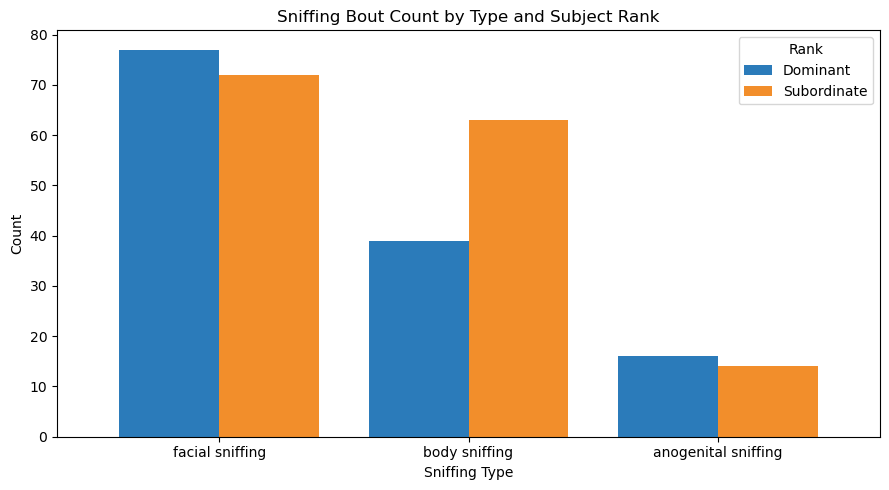

In [6]:
# Prepare a grouped bar plot: x-axis is Behavior (sniffing type), grouped by Rank
# feature_matrix was balanced in the cell above (sniffing types + matched Rank counts)
sniff_behaviors = ["facial sniffing", "body sniffing", "anogenital sniffing"]
plot_df = feature_matrix.copy()

rank_order = sorted(plot_df["Rank"].unique())
behavior_order = sniff_behaviors

# Count by [Behavior, Rank]
count_df = (
    plot_df
    .groupby(["Behavior", "Rank"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=behavior_order, fill_value=0)
    .reindex(columns=rank_order)
)

# Plot
ax = count_df.plot(
    kind="bar",
    figsize=(9, 5),
    width=0.8,
    color=["#2b7bba", "#f28e2b"][:len(rank_order)]
)
plt.title("Sniffing Bout Count by Type and Subject Rank")
plt.ylabel("Count")
plt.xlabel("Sniffing Type")
plt.legend(title="Rank")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
feature_matrix.head()

,Behavior,Initiator,Start,Stop,Duration,PreBoutRespRate,Trial,Subject,social_agent,Cohort,Rank,Type,h5_path,h5_filename,boris_path,boris_filename,FeatureWindow,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_ibi,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,...,mean_inhale_pause_dur_sec_z_trial,cv_inhale_pause_dur_z_subject,cv_inhale_pause_dur_z_trial,inhale_pause_duty_cycle_z_subject,inhale_pause_duty_cycle_z_trial,pct_breaths_with_exhale_pause_z_subject,pct_breaths_with_exhale_pause_z_trial,mean_exhale_pause_dur_sec_z_subject,mean_exhale_pause_dur_sec_z_trial,cv_exhale_pause_dur_z_subject,cv_exhale_pause_dur_z_trial,exhale_pause_duty_cycle_z_subject,exhale_pause_duty_cycle_z_trial,inhale_duty_cycle_z_subject,inhale_duty_cycle_z_trial,exhale_duty_cycle_z_subject,exhale_duty_cycle_z_trial,resp_rate_delta_z_subject,resp_rate_delta_z_trial,breathing_rate_z_z_subject,breathing_rate_z_z_trial,vol_asymmetry_z_subject,vol_asymmetry_z_trial,peak_flow_ratio_z_subject,peak_flow_ratio_z_trial
0,facial sniffing,social_agent,16.500,18.500,2.0,11.336032,AIM1cm_2_3_2_4_20250623_151153,2_3,2_4,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153.1.csv,full,23,11.340206,0.088182,0.056818,0.039457,0.128033,0.043804,0.192528,...,-0.248851,NaN,NaN,-0.250331,-0.250331,-0.744598,-0.744598,-0.518062,-0.518062,NaN,NaN,-0.538419,-0.538419,0.329283,0.329283,-0.210577,-0.210577,-0.183683,-0.183683,1.967566,1.967566,-0.017091,-0.017091,-0.637966,-0.637966
1,facial sniffing,subject,16.567,18.567,2.0,11.384217,AIM1cm_2_3_2_4_20250623_151153,2_3,2_4,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153.1.csv,full,23,11.311054,0.088409,0.056262,0.039130,0.134026,0.044348,0.193301,...,-0.248851,NaN,NaN,-0.250331,-0.250331,-0.744598,-0.744598,-0.518062,-0.518062,NaN,NaN,-0.538419,-0.538419,0.237698,0.237698,-0.155480,-0.155480,-0.214181,-0.214181,1.949087,1.949087,-0.149291,-0.149291,-0.795817,-0.795817
2,body sniffing,subject,17.700,19.700,2.0,11.354839,AIM1cm_2_3_2_4_20250623_151153,2_3,2_4,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153.1.csv,full,20,10.066225,0.099342,0.390789,0.046375,0.705865,0.048125,0.392156,...,-0.248851,NaN,NaN,-0.250331,-0.250331,-0.744598,-0.744598,-0.518062,-0.518062,NaN,NaN,-0.538419,-0.538419,0.696031,0.696031,-0.349875,-0.349875,-0.693495,-0.693495,1.160016,1.160016,-0.290086,-0.290086,-0.993803,-0.993803
3,anogenital sniffing,subject,21.400,23.400,2.0,9.638554,AIM1cm_2_3_2_4_20250623_151153,2_3,2_4,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153.1.csv,full,23,11.224490,0.089091,0.065834,0.040435,0.158579,0.043913,0.107267,...,-0.248851,NaN,NaN,-0.250331,-0.250331,-0.744598,-0.744598,-0.518062,-0.518062,NaN,NaN,-0.538419,-0.538419,0.450700,0.450700,-0.254118,-0.254118,0.440086,0.440086,1.894216,1.894216,-0.095399,-0.095399,-0.942901,-0.942901
4,facial sniffing,social_agent,25.200,27.200,2.0,9.947644,AIM1cm_2_3_2_4_20250623_151153,2_3,2_4,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153.1.csv,full,17,8.409987,0.118906,0.764308,0.062206,1.251447,0.051324,0.864466,...,-0.248851,NaN,NaN,-0.250331,-0.250331,-0.744598,-0.744598,-0.518062,-0.518062,NaN,NaN,-0.538419,-0.538419,1.762225,1.762225,-0.947270,-0.947270,-0.791706,-0.791706,0.110160,0.110160,0.665772,0.665772,0.275877,0.275877


In [8]:
# Remove metadata columns except 'Behavior'
metadata_cols = [
    'Initiator', 'Start', 'Stop', 'Trial', 'Subject', 'social_agent', 'Cohort',
    'Rank', 'Type', 'h5_path', 'h5_filename', 'boris_path', 'boris_filename',
    'FeatureWindow', 'Condition', 'SessionRate', 'BoutID', 'PreBoutRespRate'
]
non_feature_cols = ['Behavior'] + [col for col in feature_matrix.columns if (
    feature_matrix[col].dtype == 'O' or col in metadata_cols
) and col != 'Behavior']

resp_features = [col for col in feature_matrix.columns if col not in non_feature_cols]

In [9]:
# Print the most correlating feature pairs for each Rank group
for group_label in feature_matrix['Rank'].unique():
    group_df = feature_matrix[feature_matrix['Rank'] == group_label]
    sub_df = group_df[resp_features].copy()
    # Only include columns with more than 1 value and at least 2 non-NaN entries
    valid_cols = [
        col for col in sub_df.columns
        if sub_df[col].notna().sum() > 1 and sub_df[col].nunique(dropna=True) > 1
    ]
    corr = sub_df[valid_cols].corr(method='pearson')
    corr_vals = corr.abs().where(~np.eye(corr.shape[0], dtype=bool))
    # Find the single most correlated pair (absolute value)
    stack_corr = corr_vals.stack()
    if stack_corr.empty:
        print(f"\nNo valid correlations for Rank {group_label}")
        continue
    max_pair = stack_corr.idxmax()
    max_val = stack_corr.max()
    print(f"\nRank: {group_label}")
    print(f"  Most correlated features: {max_pair[0]} <-> {max_pair[1]} | r = {corr.loc[max_pair[0], max_pair[1]]:.2f}")


Rank: Subordinate
  Most correlated features: breathing_rate_z <-> breathing_rate_hz_z_subject | r = 1.00

Rank: Dominant
  Most correlated features: breathing_rate_z <-> breathing_rate_hz_z_subject | r = 1.00


In [10]:
len(feature_matrix)

281

In [11]:
# Compute per-subject correlation matrices within each Rank group,
# then average those matrices per group to get "mean group correlation matrices."
# Finally, report feature pairs with the biggest *difference* in correlation between groups.
import itertools

ranks = feature_matrix['Rank'].dropna().unique()
subject_corrs_by_rank = {rank: [] for rank in ranks}
subjects_by_rank = {rank: feature_matrix[feature_matrix['Rank'] == rank]['Subject'].unique()
                    for rank in ranks}

# 1. For each subject in each Rank, compute correlation matrix for all valid features
for rank_label in ranks:
    group_df = feature_matrix[feature_matrix['Rank'] == rank_label]
    # get all subjects in this group
    for subj in group_df['Subject'].unique():
        subj_df = group_df[group_df['Subject'] == subj]
        valid_cols = [
            col for col in resp_features
            if subj_df[col].notna().sum() > 2 and subj_df[col].nunique(dropna=True) > 1
        ]
        # Only keep if enough features for a matrix
        if len(valid_cols) >= 2:
            corr = subj_df[valid_cols].corr(method='pearson')
            # Only store if not empty AND at least 2 effective features
            if corr.shape[0] >= 2:
                subject_corrs_by_rank[rank_label].append(corr)

# 2. Find common features that are present in all subjects for both groups,
# to fairly compare: take intersection across all subjects in both groups
all_corrs = sum(subject_corrs_by_rank.values(), [])
if len(all_corrs) == 0:
    raise ValueError("No valid subject correlation matrices found.")
shared_cols = set(all_corrs[0].columns)
for corr in all_corrs[1:]:
    shared_cols &= set(corr.columns)
shared_cols = sorted(shared_cols)
print(f"Shared feature count for subject-level averaging: {len(shared_cols)}")

# 3. For each subject matrix, reindex to shared_cols and fill missing with NaN
def reindex_and_fill(mat, cols):
    return mat.reindex(index=cols, columns=cols)

mean_corrs_by_rank = {}
for rank in ranks:
    stacked = [reindex_and_fill(m, shared_cols) for m in subject_corrs_by_rank[rank]]
    # Stack (N, F, F) then mean over axis=0 (subject average)
    corr_stack = np.stack([m.values for m in stacked])
    mean_matrix = np.nanmean(corr_stack, axis=0)
    mean_corrs_by_rank[rank] = pd.DataFrame(mean_matrix, index=shared_cols, columns=shared_cols)

# 4. ΔR = R_sub - R_dom (for 2 ranks: "Subordinate" minus "Dominant")
if len(ranks) != 2:
    raise ValueError("This code assumes exactly 2 Ranks for delta calculation.")
rank1, rank2 = ranks
delta_corr = mean_corrs_by_rank[rank2] - mean_corrs_by_rank[rank1]  # e.g., Subordinate - Dominant

# 5. Scan the off-diagonal feature pairs for the largest differences in correlation (by absolute value)
correlation_deltas = []
for f1, f2 in itertools.combinations(shared_cols, 2):
    r1 = mean_corrs_by_rank[rank1].loc[f1, f2]
    r2 = mean_corrs_by_rank[rank2].loc[f1, f2]
    delta = r2 - r1
    abs_delta = abs(delta)
    correlation_deltas.append({
        'feature_1': f1,
        'feature_2': f2,
        f'{rank1}_r': r1,
        f'{rank2}_r': r2,
        'delta': delta,
        'abs_delta': abs_delta,
        'higher_in': rank2 if abs(r2) > abs(r1) else rank1,
    })

# Sort and display
top_n = 10
top_differential_pairs = sorted(correlation_deltas, key=lambda x: x['abs_delta'], reverse=True)[:top_n]

print(f"\nTop {top_n} feature pairs with the *largest* difference in mean subject correlation between Rank groups:")
for i, row in enumerate(top_differential_pairs, 1):
    print(
        f"{i}. {row['feature_1']} <-> {row['feature_2']} | "
        f"{rank1} r = {row[f'{rank1}_r']:.2f}, "
        f"{rank2} r = {row[f'{rank2}_r']:.2f}, "
        f"Δr = {row['delta']:.2f}"
    )


Shared feature count for subject-level averaging: 81

Top 10 feature pairs with the *largest* difference in mean subject correlation between Rank groups:
1. cv_inhale_vol_z_subject <-> peak_flow_ratio | Subordinate r = -0.56, Dominant r = 0.26, Δr = 0.81
2. cv_inhale_vol_z_subject <-> peak_flow_ratio_z_subject | Subordinate r = -0.56, Dominant r = 0.26, Δr = 0.81
3. cv_inhale_vol_z_subject <-> peak_flow_ratio_z_trial | Subordinate r = -0.56, Dominant r = 0.26, Δr = 0.81
4. cv_inhale_vol_z_trial <-> peak_flow_ratio | Subordinate r = -0.56, Dominant r = 0.26, Δr = 0.81
5. cv_inhale_vol_z_trial <-> peak_flow_ratio_z_subject | Subordinate r = -0.56, Dominant r = 0.26, Δr = 0.81
6. cv_inhale_vol_z_trial <-> peak_flow_ratio_z_trial | Subordinate r = -0.56, Dominant r = 0.26, Δr = 0.81
7. cv_inhale_vol <-> peak_flow_ratio | Subordinate r = -0.56, Dominant r = 0.26, Δr = 0.81
8. cv_inhale_vol <-> peak_flow_ratio_z_subject | Subordinate r = -0.56, Dominant r = 0.26, Δr = 0.81
9. cv_inhale_vol <

In [15]:
AIM1_FEATURE_MATRIX = feature_matrix[feature_matrix['Cohort']=="Aim1"]

In [18]:
AIM1_FEATURE_MATRIX["Subject"].nunique()

5

In [17]:
ds

NameError: name 'ds' is not defined

Number of Dominant subjects: 2
Number of Subordinate subjects: 3
Dominant Subjects: ['2_4', '4_8']
Subordinate Subjects: ['2_3', '3_5', '4_7']


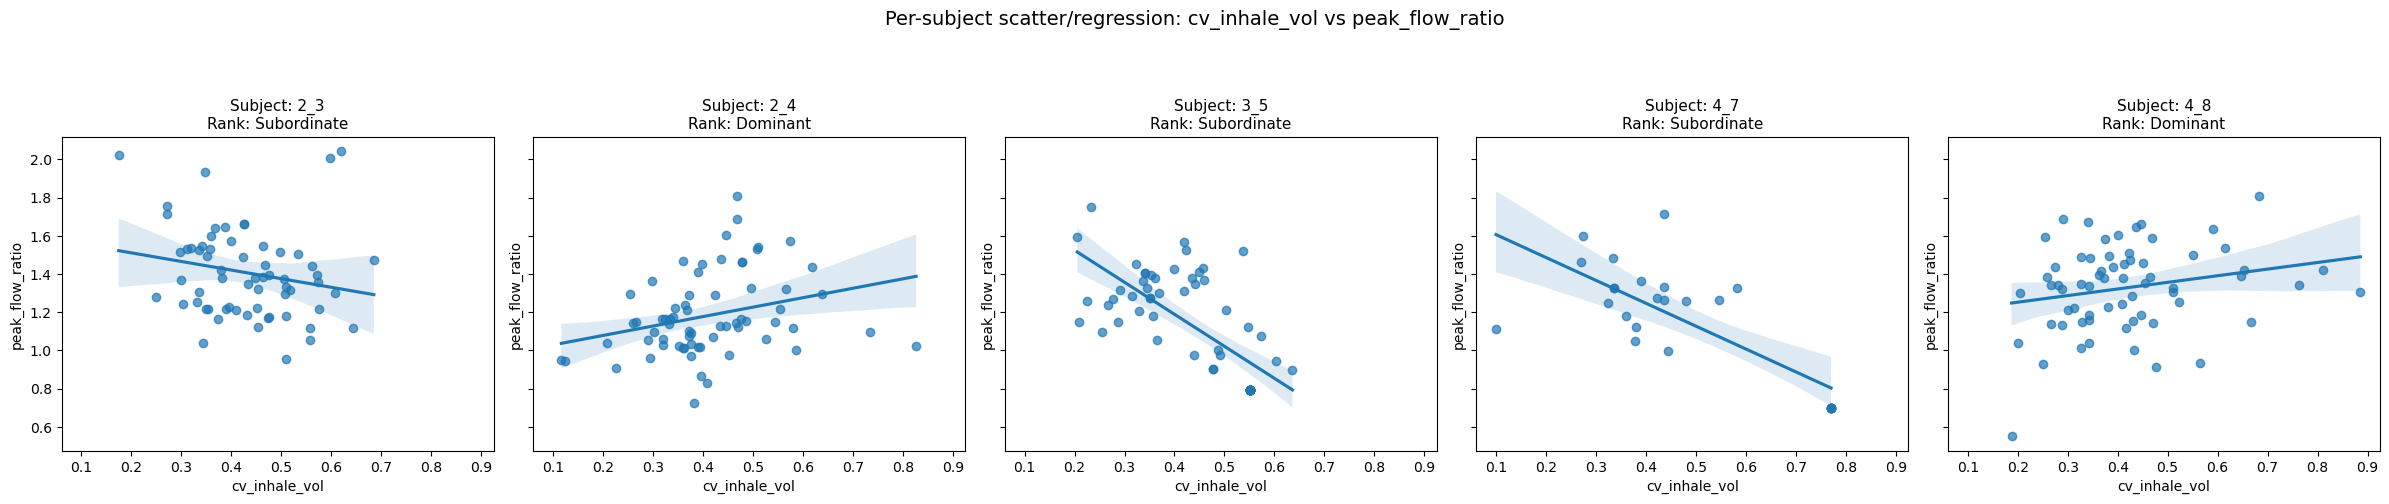

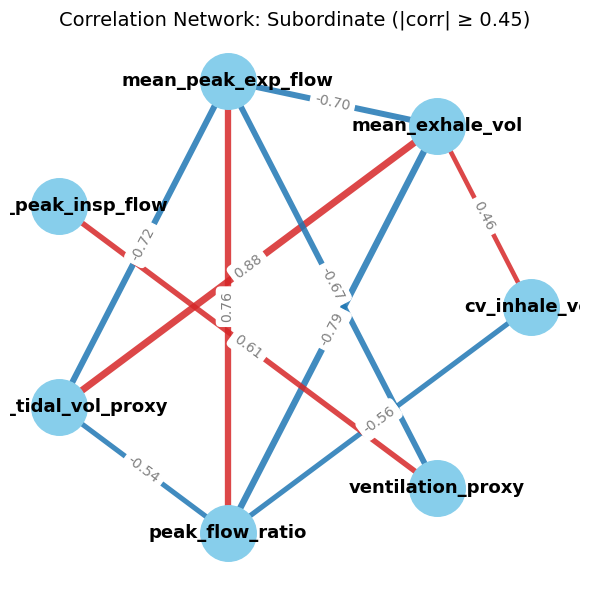

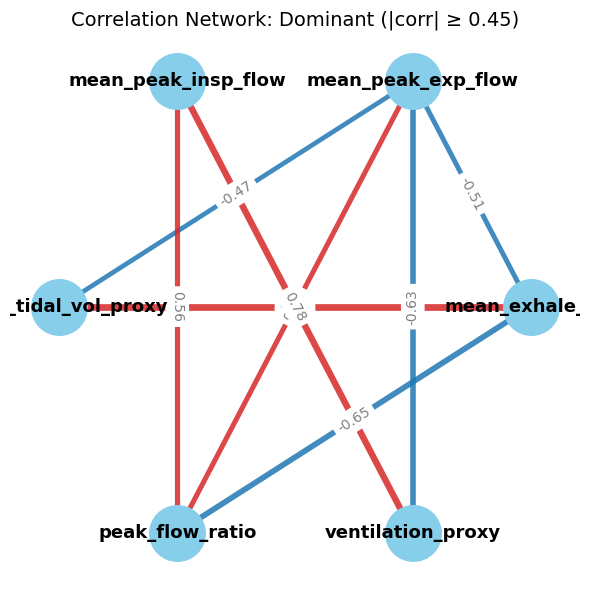


Eigenvector centrality — Subordinate:
  mean_exhale_vol: 0.513
  mean_peak_exp_flow: 0.486
  peak_flow_ratio: 0.481
  mean_tidal_vol_proxy: 0.448
  cv_inhale_vol: 0.213
  ventilation_proxy: 0.148
  mean_peak_insp_flow: 0.038

Eigenvector centrality — Dominant:
  mean_peak_exp_flow: 0.499
  mean_exhale_vol: 0.496
  peak_flow_ratio: 0.434
  mean_tidal_vol_proxy: 0.377
  ventilation_proxy: 0.310
  mean_peak_insp_flow: 0.281


In [ ]:

# 1. How many Dominant vs Subordinate subjects?
dominant_subjects = set(feature_matrix[feature_matrix["Rank"] == "Dominant"]["Subject"].unique())
subordinate_subjects = set(feature_matrix[feature_matrix["Rank"] == "Subordinate"]["Subject"].unique())
print(f"Number of Dominant subjects: {len(dominant_subjects)}")
print(f"Number of Subordinate subjects: {len(subordinate_subjects)}")
print(f"Dominant Subjects: {sorted(dominant_subjects)}")
print(f"Subordinate Subjects: {sorted(subordinate_subjects)}")

# 2. Per-subject scatter plots with regression lines for cv_inhale_vol vs peak_flow_ratio

PAIR_1_X = "cv_inhale_vol"
PAIR_1_Y = "peak_flow_ratio"
all_subjects = sorted(feature_matrix["Subject"].unique())

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, len(all_subjects), figsize=(4.8 * len(all_subjects), 4.8), sharex=True, sharey=True)
if len(all_subjects) == 1:
    axes = [axes]
for i, subj in enumerate(all_subjects):
    subj_data = feature_matrix[feature_matrix["Subject"] == subj]
    sns.regplot(
        x=PAIR_1_X, y=PAIR_1_Y, data=subj_data,
        ax=axes[i], scatter_kws={'alpha': 0.7}
    )
    rank = subj_data['Rank'].iloc[0] if not subj_data.empty else "?"
    axes[i].set_title(f"Subject: {subj}\nRank: {rank}", fontsize=11)
    axes[i].set_xlabel(PAIR_1_X)
    axes[i].set_ylabel(PAIR_1_Y)
plt.suptitle(f"Per-subject scatter/regression: {PAIR_1_X} vs {PAIR_1_Y}", fontsize=14, y=1.08)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

# 3. Network plot for each rank group

try:
    import networkx as nx

    # Focus on a smaller subset for simpler plots (choose fewer features with interpretability)
    network_features = [
        "cv_inhale_vol",
        "mean_tidal_vol_proxy",
        "mean_peak_exp_flow",
        "mean_peak_insp_flow",
        "ventilation_proxy",
        "mean_exhale_vol",
        "peak_flow_ratio"
    ]
    network_features = [f for f in network_features if f in shared_cols]

    def plot_correlation_network(corr_matrix, features, group_label, threshold=0.45):
        # Only include nodes with at least one edge
        edges = []
        for i, f1 in enumerate(features):
            for j, f2 in enumerate(features):
                if i < j:
                    val = corr_matrix.loc[f1, f2]
                    if abs(val) >= threshold:
                        edges.append((f1, f2, val))
        kept_nodes = sorted(set(f for edge in edges for f in edge[:2]))
        if not kept_nodes:
            print(f"\nNo feature pairs with |corr| >= {threshold} for {group_label}")
            return nx.Graph()
        G = nx.Graph()
        for f in kept_nodes:
            G.add_node(f)
        for f1, f2, val in edges:
            G.add_edge(f1, f2, weight=abs(val), corr=val)
        # Layout - circular for clarity if small, else spring
        pos = nx.circular_layout(G) if len(G) <= 7 else nx.spring_layout(G, seed=42)
        edge_colors = [
            "tab:red" if G.edges[e]["corr"] > 0 else "tab:blue"
            for e in G.edges
        ]
        edge_widths = [
            1.5 + 4.0 * abs(G.edges[e]["corr"])
            for e in G.edges
        ]
        plt.figure(figsize=(6, 6))
        nx.draw_networkx_nodes(G, pos, node_color="skyblue", node_size=1600)
        nx.draw_networkx_labels(G, pos, font_size=13, font_weight='bold')
        nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, alpha=0.85)
        nx.draw_networkx_edge_labels(
            G, pos,
            edge_labels={
                e: f"{G.edges[e]['corr']:.2f}" for e in G.edges
            },
            font_color='gray', font_size=10
        )
        plt.title(f"Correlation Network: {group_label} (|corr| ≥ {threshold})", fontsize=14)
        plt.tight_layout()
        plt.axis('off')
        plt.show()
        return G

    # Plot for Dominant
    G_dominant = plot_correlation_network(
        mean_corrs_by_rank[rank1], network_features, group_label=rank1
    )
    # Plot for Subordinate
    G_subordinate = plot_correlation_network(
        mean_corrs_by_rank[rank2], network_features, group_label=rank2
    )

    # 4. Eigenvector centrality per group
    def safe_eigenvector_centrality(G, name):
        # Only run if connected, else skip and warn user
        if G.number_of_nodes() == 0:
            print(f"\nNo edges in {name}'s network; skipping eigenvector centrality.")
            return None
        try:
            if nx.is_connected(G):
                ec = nx.eigenvector_centrality_numpy(G, weight="weight")
                print(f"\nEigenvector centrality — {name}:")
                for f, val in sorted(ec.items(), key=lambda x: x[1], reverse=True):
                    print(f"  {f}: {val:.3f}")
                return ec
            else:
                print(f"\n[Skipped] {name} network graph is disconnected; cannot compute eigenvector centrality.")
                return None
        except Exception as e:
            print(f"\n[Skipped] Could not compute eigenvector centrality for {name}: {e}")
            return None

    ec_dom = safe_eigenvector_centrality(G_dominant, rank1)
    ec_sub = safe_eigenvector_centrality(G_subordinate, rank2)

except ModuleNotFoundError:
    print(
        "\n[NetworkX not found] To enable the correlation network visualizations, please install the 'networkx' package.\n"
        "You can install it using:\n"
        "  pip install networkx\n"
        "or in a Jupyter notebook cell:\n"
        "  !pip install networkx"
    )


Number of Dominant subjects: 5
Number of Subordinate subjects: 8
Dominant Subjects: ['1_2', '2_4', '4_2', '4_8', '7_1']
Subordinate Subjects: ['1_1', '2_3', '3_5', '4_1', '4_7', '7_2', '8_1', '8_2']
Subject: 1_1 | Rank: Subordinate | Cohort: BLA
  Linear regression (cv_inhale_vol vs peak_flow_ratio): slope = 0.002, intercept = 1.437, R² = 0.000, p = 0.981



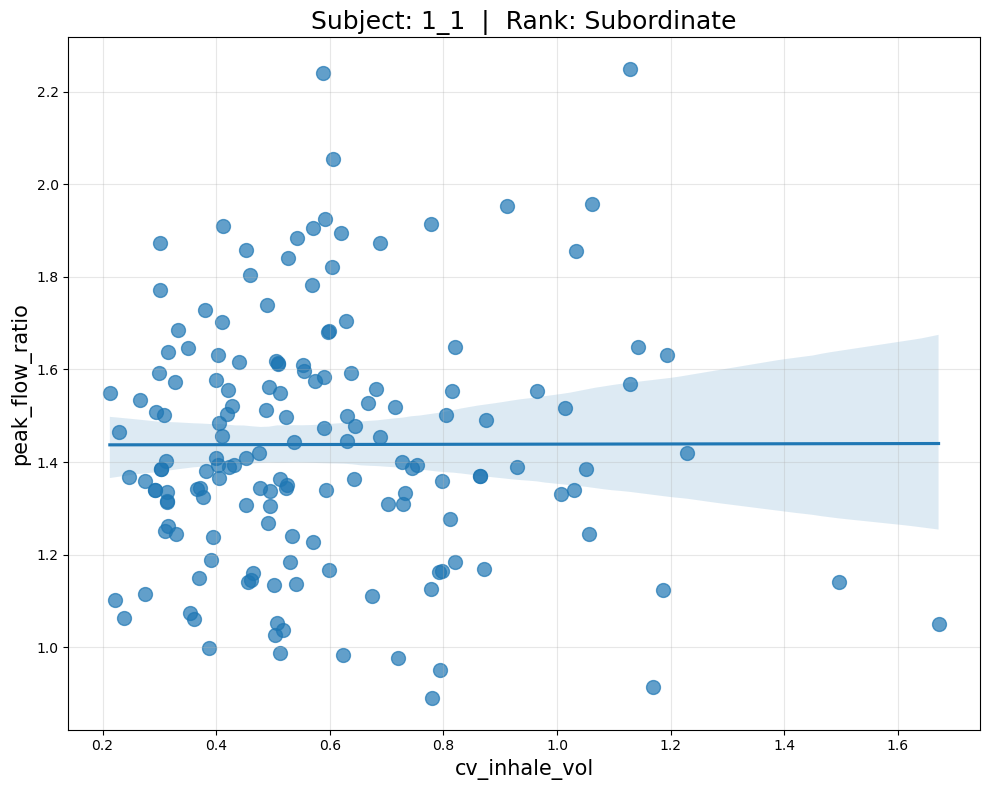

Subject: 1_2 | Rank: Dominant | Cohort: BLA
  Linear regression (cv_inhale_vol vs peak_flow_ratio): slope = 0.110, intercept = 1.571, R² = 0.005, p = 0.654



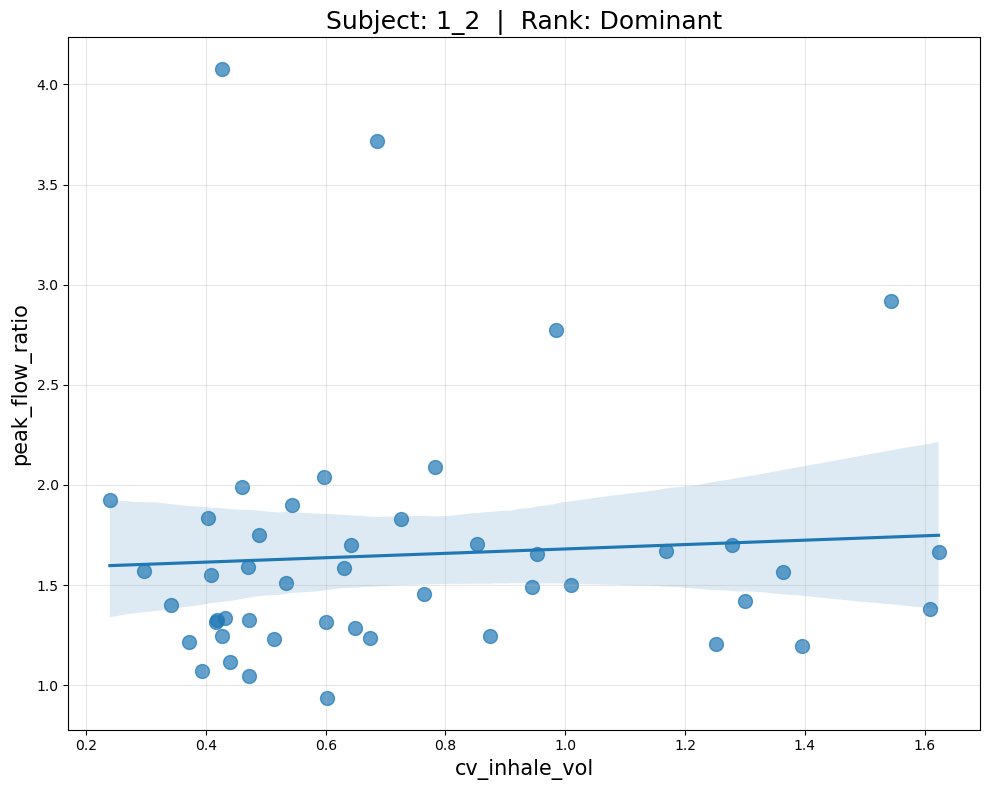

Subject: 2_3 | Rank: Subordinate | Cohort: Aim1
  Linear regression (cv_inhale_vol vs peak_flow_ratio): slope = -0.451, intercept = 1.601, R² = 0.041, p = 0.11



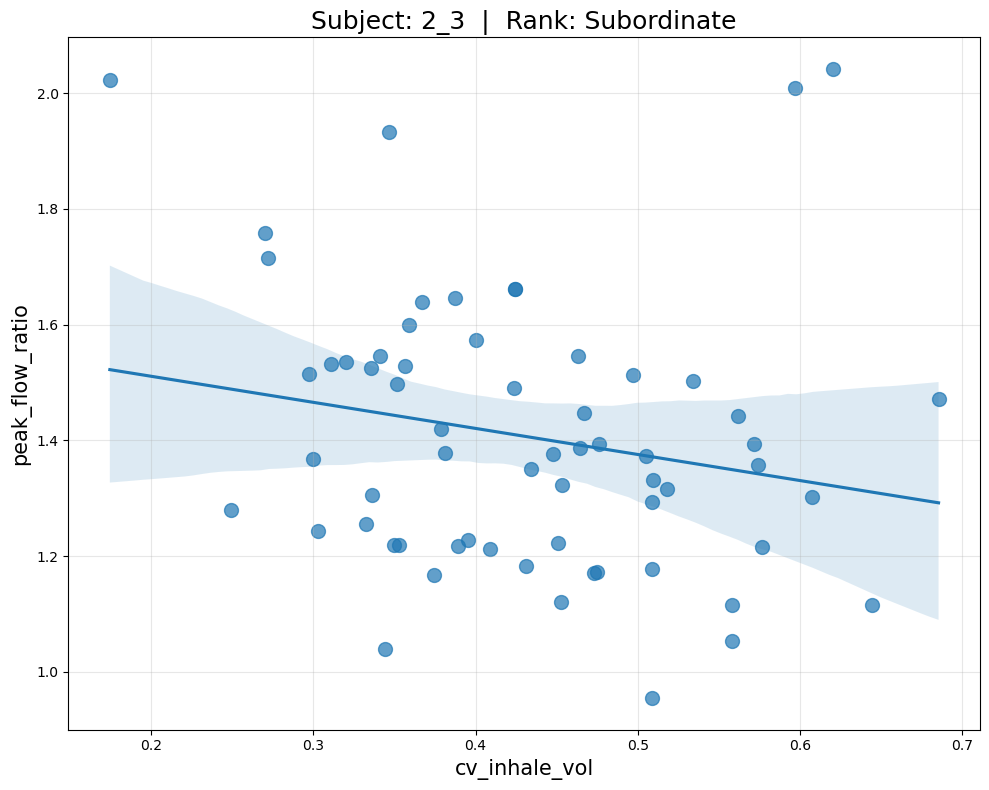

Subject: 2_4 | Rank: Dominant | Cohort: Aim1
  Linear regression (cv_inhale_vol vs peak_flow_ratio): slope = 0.494, intercept = 0.979, R² = 0.085, p = 0.017



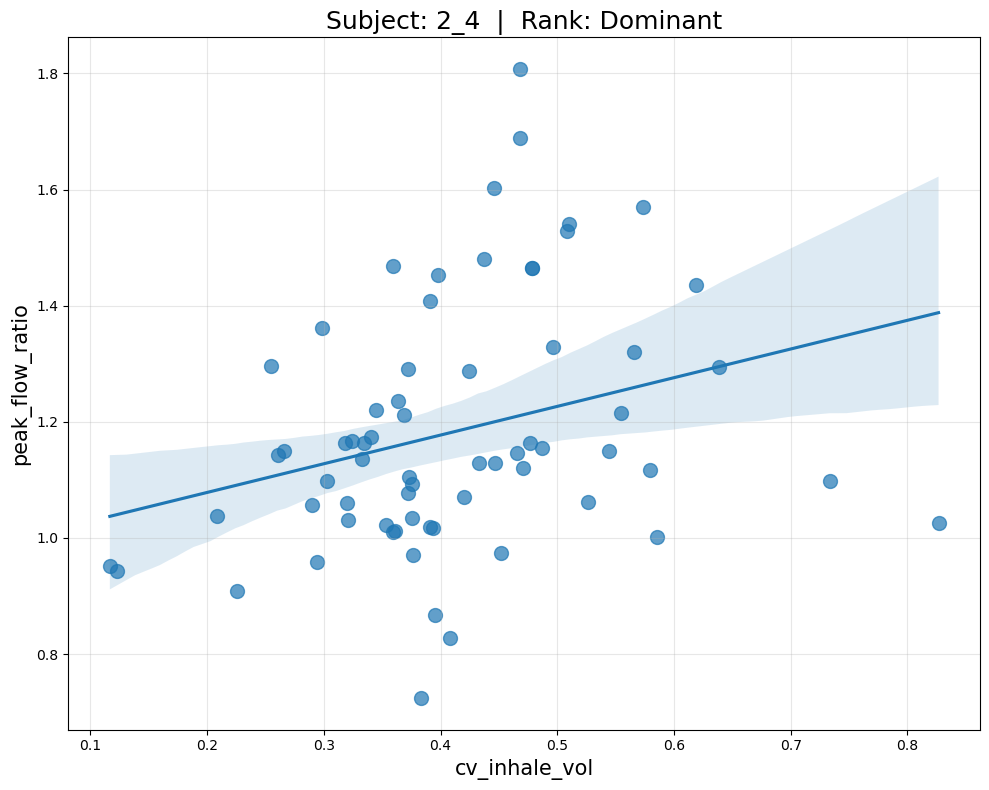

Subject: 3_5 | Rank: Subordinate | Cohort: Aim1
  Linear regression (cv_inhale_vol vs peak_flow_ratio): slope = -1.677, intercept = 1.860, R² = 0.495, p = 2.54e-10



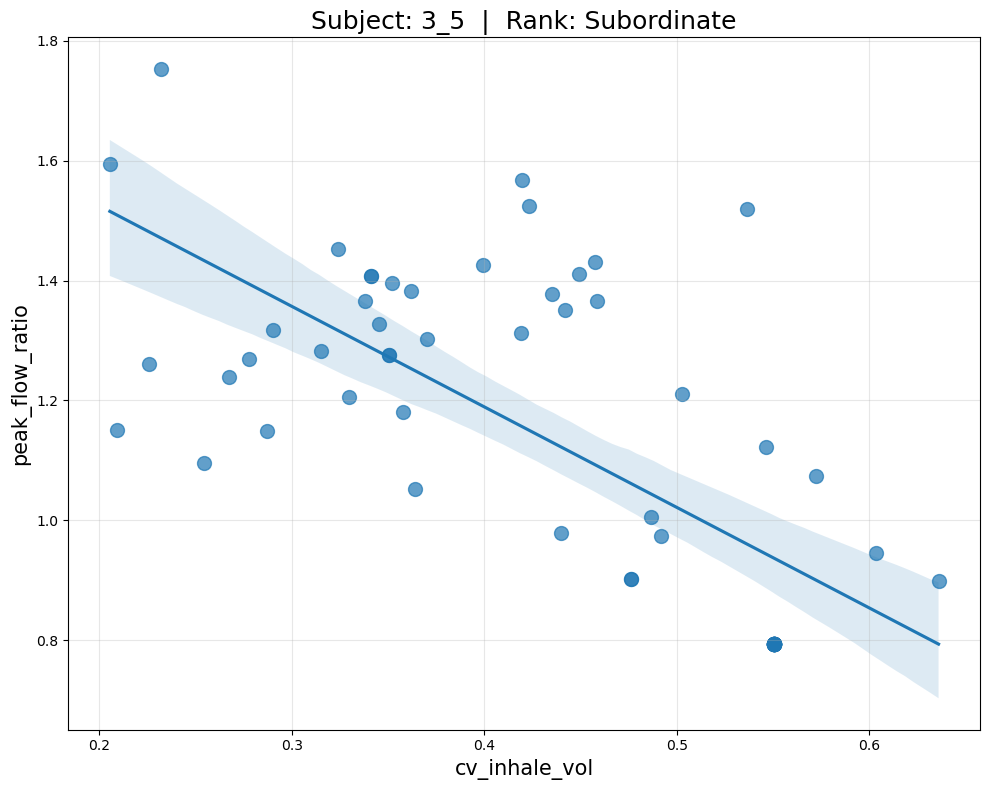

Subject: 4_1 | Rank: Subordinate | Cohort: BLA
  Linear regression (cv_inhale_vol vs peak_flow_ratio): slope = 0.107, intercept = 1.429, R² = 0.016, p = 0.338



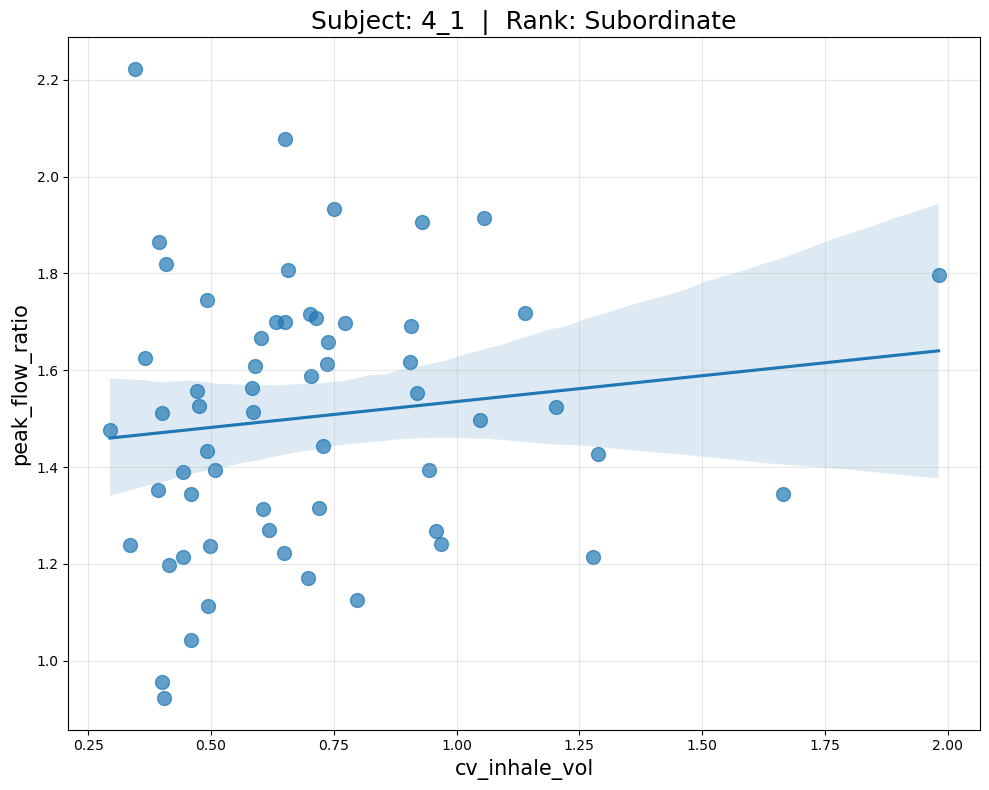

Subject: 4_2 | Rank: Dominant | Cohort: BLA
  Linear regression (cv_inhale_vol vs peak_flow_ratio): slope = 0.065, intercept = 1.481, R² = 0.003, p = 0.708



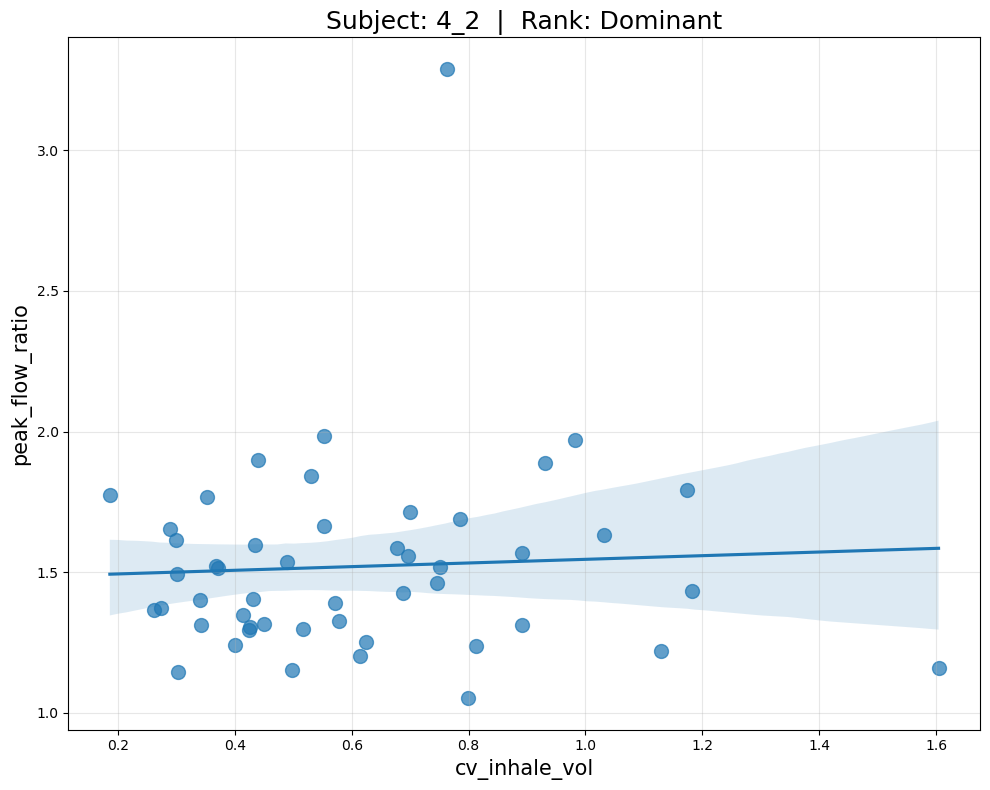

Subject: 4_7 | Rank: Subordinate | Cohort: Aim1
  Linear regression (cv_inhale_vol vs peak_flow_ratio): slope = -1.198, intercept = 1.726, R² = 0.576, p = 1.09e-05



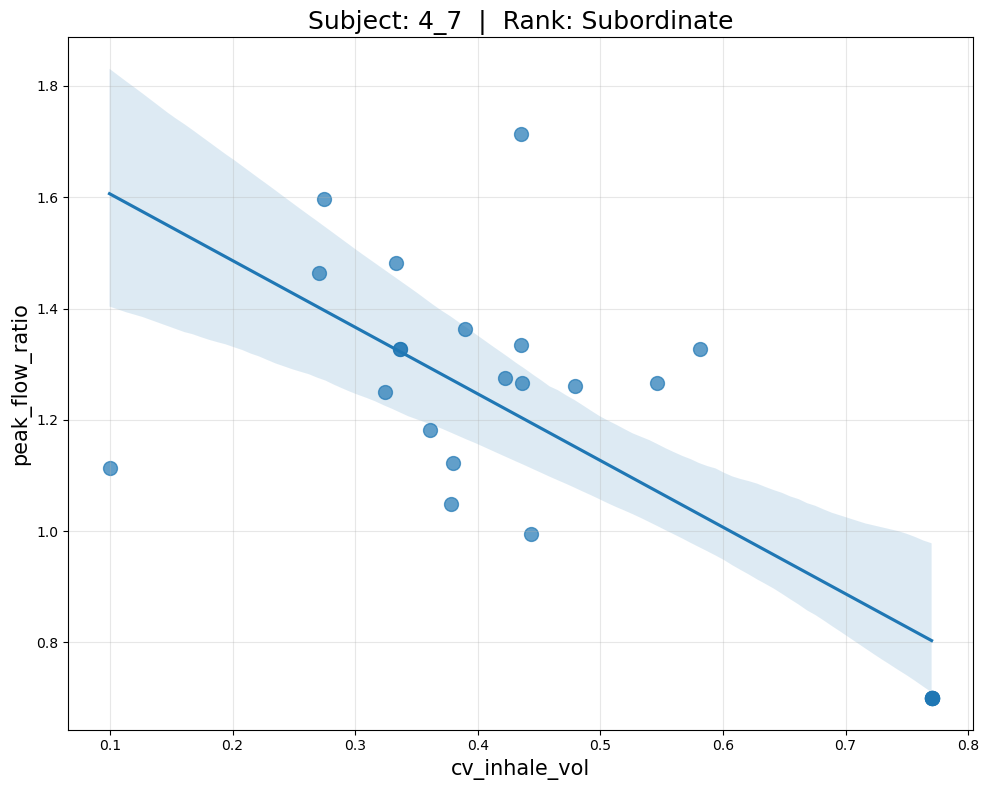

Subject: 4_8 | Rank: Dominant | Cohort: Aim1
  Linear regression (cv_inhale_vol vs peak_flow_ratio): slope = 0.347, intercept = 1.183, R² = 0.051, p = 0.0717



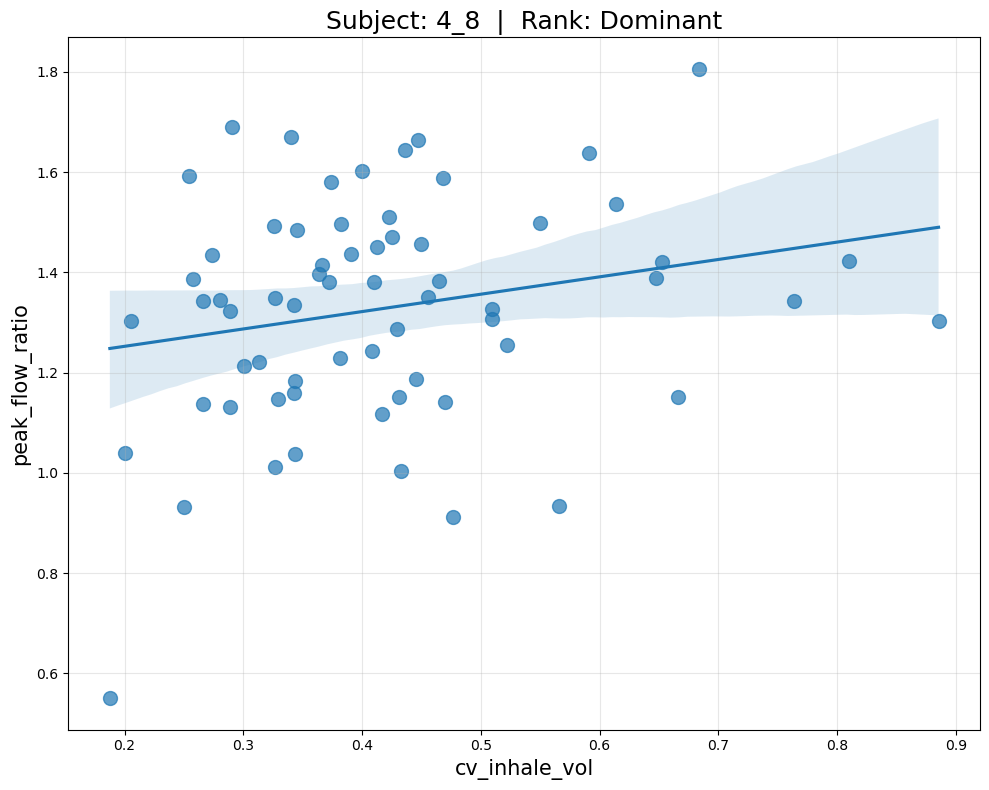

Subject: 7_1 | Rank: Dominant | Cohort: BLA
  Linear regression (cv_inhale_vol vs peak_flow_ratio): slope = 0.111, intercept = 1.345, R² = 0.017, p = 0.282



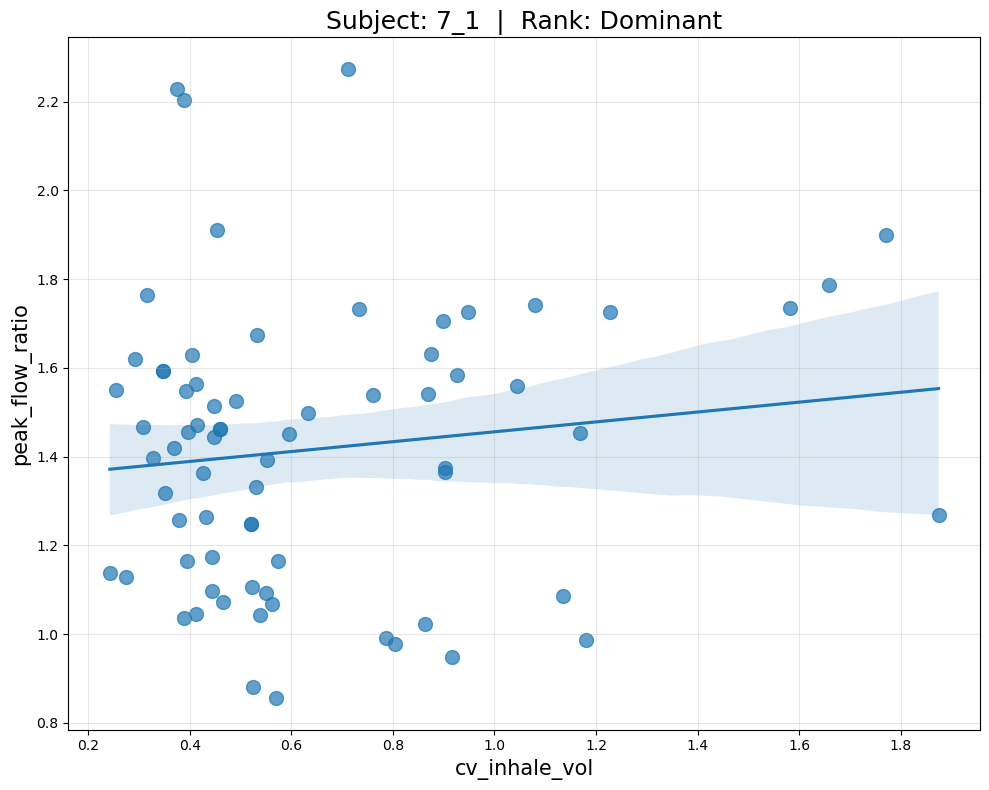

Subject: 7_2 | Rank: Subordinate | Cohort: BLA
  Linear regression (cv_inhale_vol vs peak_flow_ratio): slope = 0.073, intercept = 1.716, R² = 0.005, p = 0.56



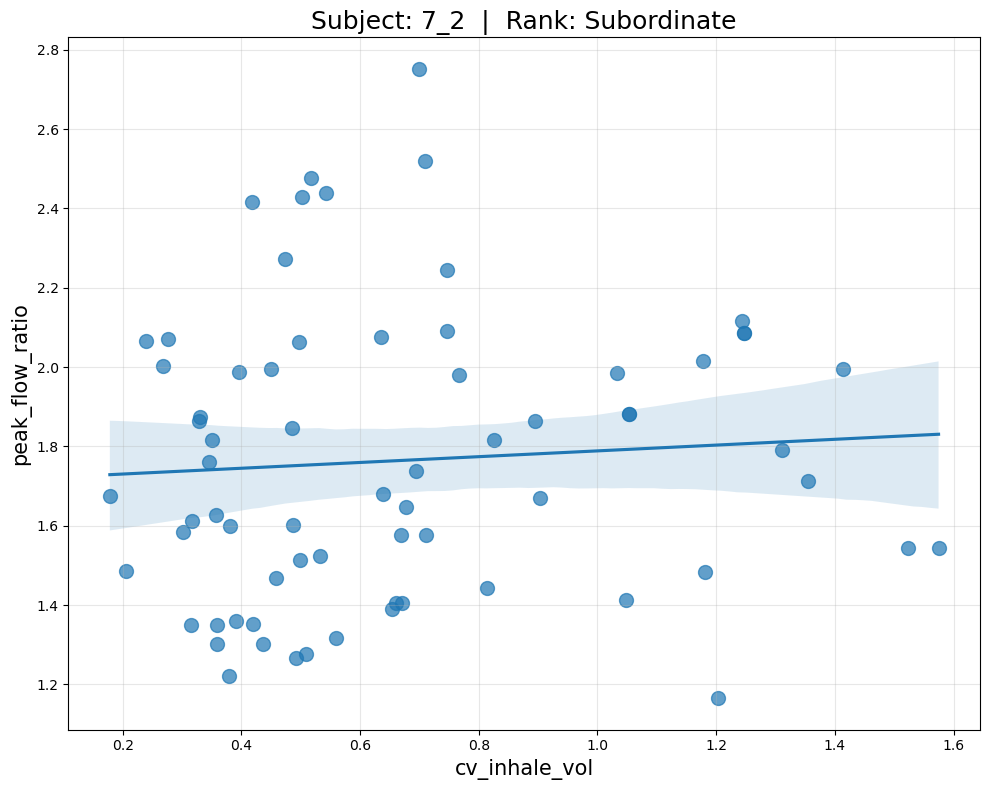

Subject: 8_1 | Rank: Subordinate | Cohort: BLA
  Linear regression (cv_inhale_vol vs peak_flow_ratio): slope = -0.104, intercept = 1.456, R² = 0.015, p = 0.453



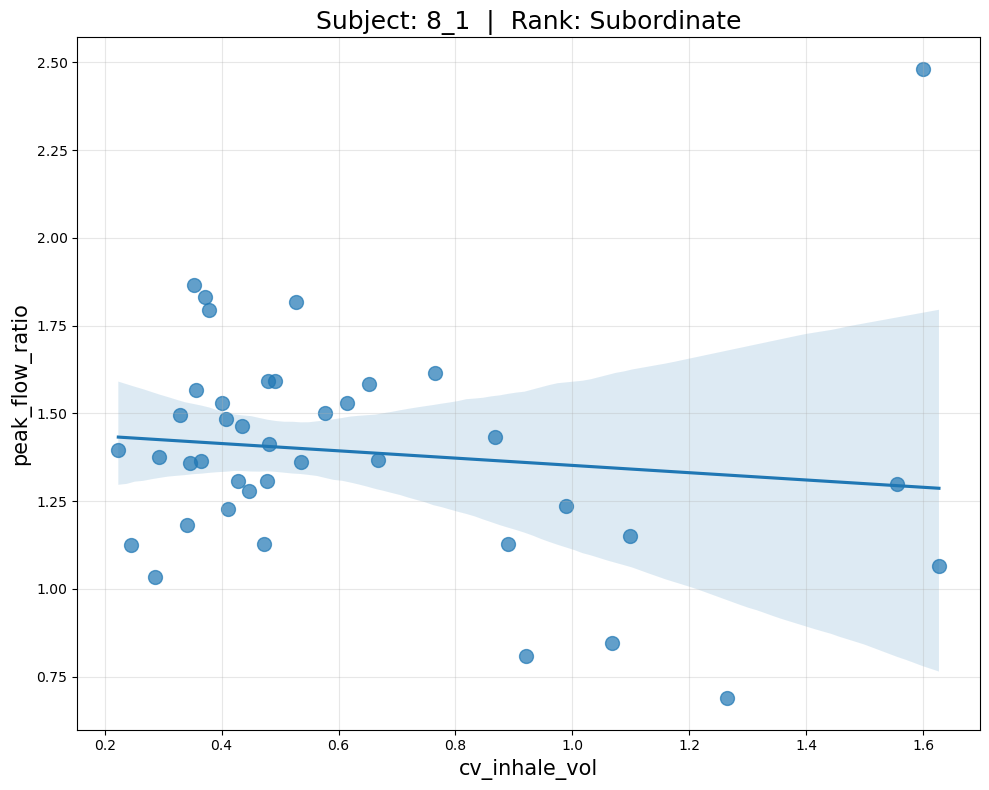

Subject: 8_2 | Rank: Subordinate | Cohort: BLA
  Linear regression (cv_inhale_vol vs peak_flow_ratio): slope = -0.074, intercept = 1.521, R² = 0.010, p = 0.431



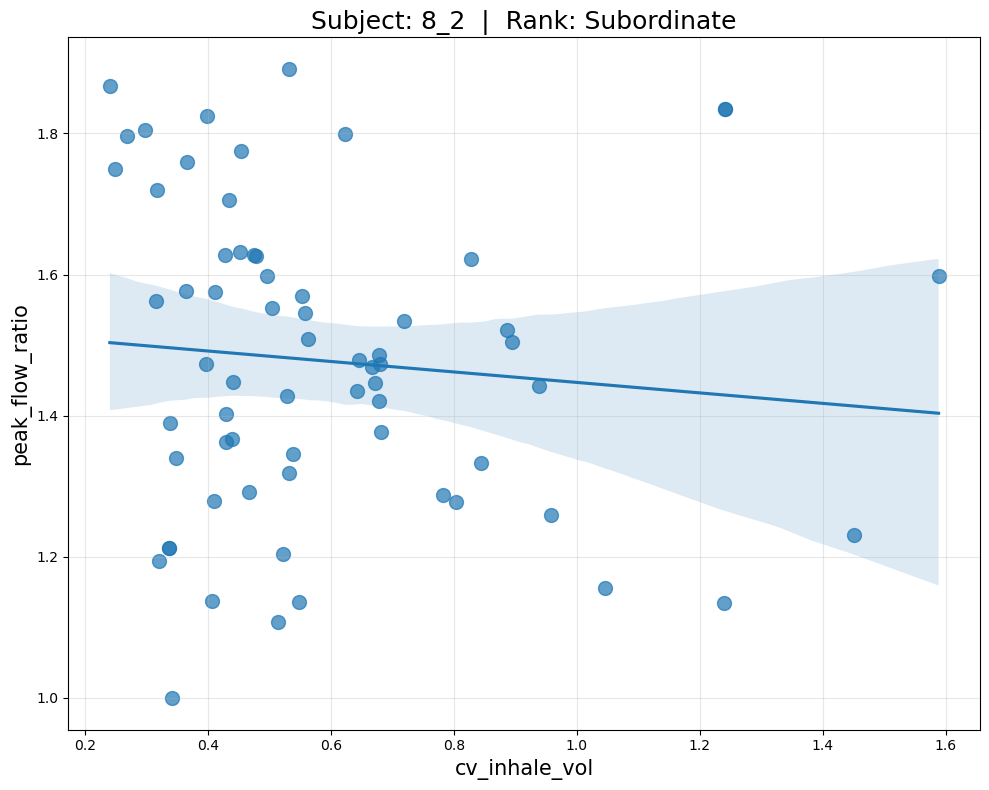

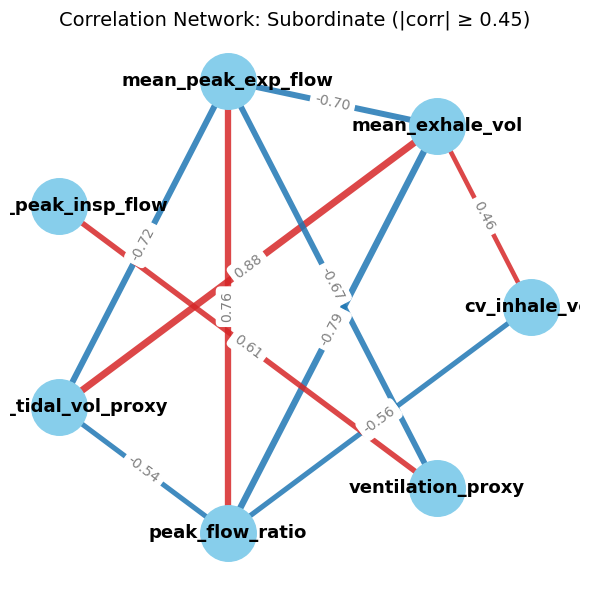

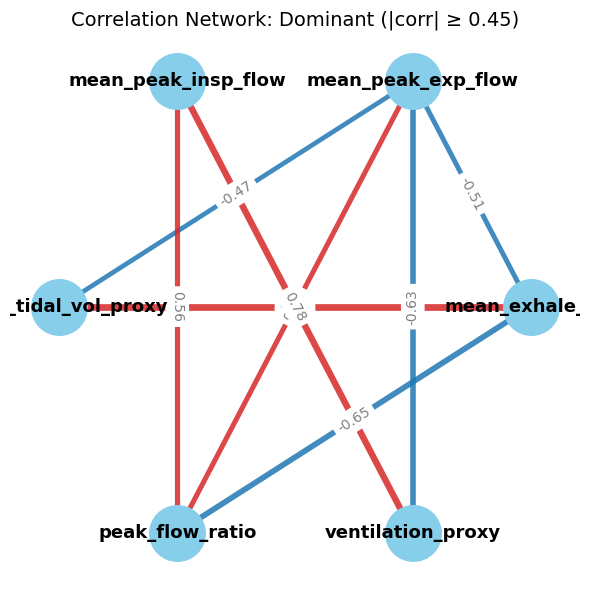


Eigenvector centrality — Subordinate:
  mean_exhale_vol: 0.513
  mean_peak_exp_flow: 0.486
  peak_flow_ratio: 0.481
  mean_tidal_vol_proxy: 0.448
  cv_inhale_vol: 0.213
  ventilation_proxy: 0.148
  mean_peak_insp_flow: 0.038

Eigenvector centrality — Dominant:
  mean_peak_exp_flow: 0.499
  mean_exhale_vol: 0.496
  peak_flow_ratio: 0.434
  mean_tidal_vol_proxy: 0.377
  ventilation_proxy: 0.310
  mean_peak_insp_flow: 0.281


In [ ]:
# 1. How many Dominant vs Subordinate subjects?
dominant_subjects = set(feature_matrix_both_cohorts[feature_matrix_both_cohorts["Rank"] == "Dominant"]["Subject"].unique())
subordinate_subjects = set(feature_matrix_both_cohorts[feature_matrix_both_cohorts["Rank"] == "Subordinate"]["Subject"].unique())
print(f"Number of Dominant subjects: {len(dominant_subjects)}")
print(f"Number of Subordinate subjects: {len(subordinate_subjects)}")
print(f"Dominant Subjects: {sorted(dominant_subjects)}")
print(f"Subordinate Subjects: {sorted(subordinate_subjects)}")

# 2. Per-subject scatter plots with regression lines for cv_inhale_vol vs peak_flow_ratio
PAIR_1_X = "cv_inhale_vol"
PAIR_1_Y = "peak_flow_ratio"
all_subjects = sorted(feature_matrix_both_cohorts["Subject"].unique())

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Show each subject's scatter plot as a large, separate figure
for subj in all_subjects:
    subj_data = feature_matrix_both_cohorts[feature_matrix_both_cohorts["Subject"] == subj]
    # Only do analysis if enough points are present
    x = subj_data[PAIR_1_X].values
    y = subj_data[PAIR_1_Y].values

    if len(x) >= 2 and len(y) >= 2 and not subj_data.empty:
        lr = linregress(x, y)
        slope = lr.slope
        intercept = lr.intercept
        r_value = lr.rvalue
        p_value = lr.pvalue
        r2 = r_value ** 2
    else:
        slope = float('nan')
        intercept = float('nan')
        r_value = float('nan')
        p_value = float('nan')
        r2 = float('nan')

    rank = subj_data['Rank'].iloc[0] if not subj_data.empty else "?"
    cohort = subj_data['Cohort'].iloc[0] if not subj_data.empty and 'Cohort' in subj_data.columns else "?"

    # Print numeric summary before plot
    print(f"Subject: {subj} | Rank: {rank} | Cohort: {cohort}")
    print(f"  Linear regression ({PAIR_1_X} vs {PAIR_1_Y}): slope = {slope:.3f}, intercept = {intercept:.3f}, R² = {r2:.3f}, p = {p_value:.3g}\n")

    # Use a large figure size for clarity
    plt.figure(figsize=(10, 8))
    sns.regplot(
        x=PAIR_1_X, y=PAIR_1_Y, data=subj_data,
        scatter_kws={'alpha': 0.7, 's': 100}
    )
    plt.title(f"Subject: {subj}  |  Rank: {rank}", fontsize=18)
    plt.xlabel(PAIR_1_X, fontsize=15)
    plt.ylabel(PAIR_1_Y, fontsize=15)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 3. Network plot for each rank group

try:
    import networkx as nx

    # Focus on a smaller subset for simpler plots (choose fewer features with interpretability)
    network_features = [
        "cv_inhale_vol",
        "mean_tidal_vol_proxy",
        "mean_peak_exp_flow",
        "mean_peak_insp_flow",
        "ventilation_proxy",
        "mean_exhale_vol",
        "peak_flow_ratio"
    ]
    network_features = [f for f in network_features if f in shared_cols]

    def plot_correlation_network(corr_matrix, features, group_label, threshold=0.45):
        # Only include nodes with at least one edge
        edges = []
        for i, f1 in enumerate(features):
            for j, f2 in enumerate(features):
                if i < j:
                    val = corr_matrix.loc[f1, f2]
                    if abs(val) >= threshold:
                        edges.append((f1, f2, val))
        kept_nodes = sorted(set(f for edge in edges for f in edge[:2]))
        if not kept_nodes:
            print(f"\nNo feature pairs with |corr| >= {threshold} for {group_label}")
            return nx.Graph()
        G = nx.Graph()
        for f in kept_nodes:
            G.add_node(f)
        for f1, f2, val in edges:
            G.add_edge(f1, f2, weight=abs(val), corr=val)
        # Layout - circular for clarity if small, else spring
        pos = nx.circular_layout(G) if len(G) <= 7 else nx.spring_layout(G, seed=42)
        edge_colors = [
            "tab:red" if G.edges[e]["corr"] > 0 else "tab:blue"
            for e in G.edges
        ]
        edge_widths = [
            1.5 + 4.0 * abs(G.edges[e]["corr"])
            for e in G.edges
        ]
        plt.figure(figsize=(6, 6))
        nx.draw_networkx_nodes(G, pos, node_color="skyblue", node_size=1600)
        nx.draw_networkx_labels(G, pos, font_size=13, font_weight='bold')
        nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=edge_colors, alpha=0.85)
        nx.draw_networkx_edge_labels(
            G, pos,
            edge_labels={
                e: f"{G.edges[e]['corr']:.2f}" for e in G.edges
            },
            font_color='gray', font_size=10
        )
        plt.title(f"Correlation Network: {group_label} (|corr| ≥ {threshold})", fontsize=14)
        plt.tight_layout()
        plt.axis('off')
        plt.show()
        return G

    # Each network plot is already a separate figure, no subplotting or horizontal alignment, so this is correct:
    # Plot for Dominant
    G_dominant = plot_correlation_network(
        mean_corrs_by_rank[rank1], network_features, group_label=rank1
    )
    # Plot for Subordinate
    G_subordinate = plot_correlation_network(
        mean_corrs_by_rank[rank2], network_features, group_label=rank2
    )

    # 4. Eigenvector centrality per group
    def safe_eigenvector_centrality(G, name):
        # Only run if connected, else skip and warn user
        if G.number_of_nodes() == 0:
            print(f"\nNo edges in {name}'s network; skipping eigenvector centrality.")
            return None
        try:
            if nx.is_connected(G):
                ec = nx.eigenvector_centrality_numpy(G, weight="weight")
                print(f"\nEigenvector centrality — {name}:")
                for f, val in sorted(ec.items(), key=lambda x: x[1], reverse=True):
                    print(f"  {f}: {val:.3f}")
                return ec
            else:
                print(f"\n[Skipped] {name} network graph is disconnected; cannot compute eigenvector centrality.")
                return None
        except Exception as e:
            print(f"\n[Skipped] Could not compute eigenvector centrality for {name}: {e}")
            return None

    ec_dom = safe_eigenvector_centrality(G_dominant, rank1)
    ec_sub = safe_eigenvector_centrality(G_subordinate, rank2)

except ModuleNotFoundError:
    print(
        "\n[NetworkX not found] To enable the correlation network visualizations, please install the 'networkx' package.\n"
        "You can install it using:\n"
        "  pip install networkx\n"
        "or in a Jupyter notebook cell:\n"
        "  !pip install networkx"
    )


In [ ]:
feature_matrix.head()

,Behavior,Initiator,Start,Stop,Duration,PreBoutRespRate,Trial,Subject,social_agent,Cohort,Rank,Type,h5_path,h5_filename,boris_path,boris_filename,FeatureWindow,n_breaths,breathing_rate_hz,mean_ibi_sec,cv_ibi,mean_inhale_dur_sec,cv_inhale_dur,mean_exhale_dur_sec,cv_exhale_dur,...,mean_inhale_pause_dur_sec_z_trial,cv_inhale_pause_dur_z_subject,cv_inhale_pause_dur_z_trial,inhale_pause_duty_cycle_z_subject,inhale_pause_duty_cycle_z_trial,pct_breaths_with_exhale_pause_z_subject,pct_breaths_with_exhale_pause_z_trial,mean_exhale_pause_dur_sec_z_subject,mean_exhale_pause_dur_sec_z_trial,cv_exhale_pause_dur_z_subject,cv_exhale_pause_dur_z_trial,exhale_pause_duty_cycle_z_subject,exhale_pause_duty_cycle_z_trial,inhale_duty_cycle_z_subject,inhale_duty_cycle_z_trial,exhale_duty_cycle_z_subject,exhale_duty_cycle_z_trial,resp_rate_delta_z_subject,resp_rate_delta_z_trial,breathing_rate_z_z_subject,breathing_rate_z_z_trial,vol_asymmetry_z_subject,vol_asymmetry_z_trial,peak_flow_ratio_z_subject,peak_flow_ratio_z_trial
0,facial sniffing,social_agent,16.500,18.500,2.0,11.336032,AIM1cm_2_3_2_4_20250623_151153,2_3,2_4,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153.1.csv,full,23,11.340206,0.088182,0.056818,0.039457,0.128033,0.043804,0.192528,...,-0.248851,NaN,NaN,-0.250331,-0.250331,-0.744598,-0.744598,-0.518062,-0.518062,NaN,NaN,-0.538419,-0.538419,0.329283,0.329283,-0.210577,-0.210577,-0.183683,-0.183683,1.967566,1.967566,-0.017091,-0.017091,-0.637966,-0.637966
1,facial sniffing,subject,16.567,18.567,2.0,11.384217,AIM1cm_2_3_2_4_20250623_151153,2_3,2_4,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153.1.csv,full,23,11.311054,0.088409,0.056262,0.039130,0.134026,0.044348,0.193301,...,-0.248851,NaN,NaN,-0.250331,-0.250331,-0.744598,-0.744598,-0.518062,-0.518062,NaN,NaN,-0.538419,-0.538419,0.237698,0.237698,-0.155480,-0.155480,-0.214181,-0.214181,1.949087,1.949087,-0.149291,-0.149291,-0.795817,-0.795817
2,body sniffing,subject,17.700,19.700,2.0,11.354839,AIM1cm_2_3_2_4_20250623_151153,2_3,2_4,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153.1.csv,full,20,10.066225,0.099342,0.390789,0.046375,0.705865,0.048125,0.392156,...,-0.248851,NaN,NaN,-0.250331,-0.250331,-0.744598,-0.744598,-0.518062,-0.518062,NaN,NaN,-0.538419,-0.538419,0.696031,0.696031,-0.349875,-0.349875,-0.693495,-0.693495,1.160016,1.160016,-0.290086,-0.290086,-0.993803,-0.993803
3,anogenital sniffing,subject,21.400,23.400,2.0,9.638554,AIM1cm_2_3_2_4_20250623_151153,2_3,2_4,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153.1.csv,full,23,11.224490,0.089091,0.065834,0.040435,0.158579,0.043913,0.107267,...,-0.248851,NaN,NaN,-0.250331,-0.250331,-0.744598,-0.744598,-0.518062,-0.518062,NaN,NaN,-0.538419,-0.538419,0.450700,0.450700,-0.254118,-0.254118,0.440086,0.440086,1.894216,1.894216,-0.095399,-0.095399,-0.942901,-0.942901
4,facial sniffing,social_agent,25.200,27.200,2.0,9.947644,AIM1cm_2_3_2_4_20250623_151153,2_3,2_4,Aim1,Subordinate,Interaction,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153_merged.h5,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...,CM_s2_3_d2_4_20250623_151153.1.csv,full,17,8.409987,0.118906,0.764308,0.062206,1.251447,0.051324,0.864466,...,-0.248851,NaN,NaN,-0.250331,-0.250331,-0.744598,-0.744598,-0.518062,-0.518062,NaN,NaN,-0.538419,-0.538419,1.762225,1.762225,-0.947270,-0.947270,-0.791706,-0.791706,0.110160,0.110160,0.665772,0.665772,0.275877,0.275877


In [ ]:
# Identify top 5 features (update as needed; use those from univariate analysis)
TOP5_FEATURES = [
    "cv_inhale_vol",  # Example
    "mean_peak_exp_flow",
    "mean_tidal_vol_proxy",
    "mean_peak_insp_flow",
    "mean_inhale_vol",
]

# Define biologically motivated interaction terms
interaction_terms = {
    "cv_inhale_vol_x_peak_flow_ratio":  ("cv_inhale_vol", "peak_flow_ratio"),
    "cv_inhale_vol_x_mean_exhale_vol":  ("cv_inhale_vol", "mean_exhale_vol"),
    "cv_inhale_vol_x_mean_peak_exp_flow": ("cv_inhale_vol", "mean_peak_exp_flow"),
    "cv_exhale_pause_dur_x_resp_rate_delta": ("cv_exhale_pause_dur", "resp_rate_delta"),
    "peak_flow_ratio_x_mean_exhale_vol": ("peak_flow_ratio", "mean_exhale_vol"),
}

# ADDITIONAL FEATURES to include in the feature matrix
ADDITIONAL_FEATURES = [
    "resp_rate_delta", 
    "cv_exhale_pause_dur",
    "mean_exhale_vol",
    "peak_flow_ratio", 
]

def add_interactions_to_feature_matrix(df):
    # Work on a copy so we don't modify the original df
    X_aug = df.copy()
    # Add the interaction terms (create as products if columns exist, else NaN)
    for inter_name, (f1, f2) in interaction_terms.items():
        if f1 in X_aug.columns and f2 in X_aug.columns:
            X_aug[inter_name] = X_aug[f1] * X_aug[f2]
        else:
            X_aug[inter_name] = np.nan
    return X_aug

# Add interaction terms to the existing feature matrix (additive; keeps all columns)
feature_matrix = add_interactions_to_feature_matrix(feature_matrix)


In [ ]:
feature_matrix["cv_inhale_vol_x_peak_flow_ratio"].head()

0    0.417129
1    0.425975
2    0.554353
3    0.510250
4    1.008499
Name: cv_inhale_vol_x_peak_flow_ratio, dtype: float64

### Clarifying Features and Targets

In [ ]:
# Rank classification: Dominant vs Subordinate during interaction bouts
TARGET_COL = "Rank"
TARGET_CLASSES = ["Dominant", "Subordinate"]
MAX_MISSING_FRAC = 0.40

EXCLUDE_FROM_FEATURES = {
    TARGET_COL,
    "Condition",
    "Behavior",
    "Start",
    "Stop",
    "Duration",
    "Trial",
    "Subject",
    "Type",
    "Label",
    "h5_path",
    "FeatureWindow",
}
if "METADATA_COLS" in globals() and isinstance(METADATA_COLS, (list, tuple, set)):
    EXCLUDE_FROM_FEATURES.update(METADATA_COLS)

ENGINEERED_FEATURE_COLS = {"vol_asymmetry", "peak_flow_ratio"}

TOP_VOLUME_FLOW_FEATS = [
    "mean_exhale_vol", "mean_tidal_vol_proxy", "ventilation_proxy",
    "mean_peak_exp_flow", "mean_peak_insp_flow", "mean_inhale_vol",
    "mean_inhale_dur_sec", "cv_ibi",
]
TOP_PLUS_RATIOS = TOP_VOLUME_FLOW_FEATS + ["vol_asymmetry", "peak_flow_ratio"]


def _is_engineered_feature(col):
    return (
        col in ENGINEERED_FEATURE_COLS
        or col.endswith("_z_subject")
        or col.endswith("_z_trial")
    )


def _baseline_numeric_cols(df):
    return [
        c for c in df.columns
        if c not in EXCLUDE_FROM_FEATURES
        and pd.api.types.is_numeric_dtype(df[c])
        and not _is_engineered_feature(c)
    ]


def add_ratio_features(df):
    df = df.copy()
    if {"mean_inhale_vol", "mean_exhale_vol"}.issubset(df.columns):
        df["vol_asymmetry"] = df["mean_inhale_vol"] / (df["mean_exhale_vol"].abs() + 1e-8)
    if {"mean_peak_insp_flow", "mean_peak_exp_flow"}.issubset(df.columns):
        df["peak_flow_ratio"] = df["mean_peak_insp_flow"] / (df["mean_peak_exp_flow"].abs() + 1e-8)
    return df


def add_z_features(df):
    df = df.copy()
    for col in _baseline_numeric_cols(df):
        df[f"{col}_z_subject"] = df.groupby("Subject")[col].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan
        )
        df[f"{col}_z_trial"] = df.groupby("Trial")[col].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan
        )
    return df


def _resolve_feature_cols(kept_cols, feature_set):
    if feature_set in ("baseline", "all"):
        return [c for c in kept_cols if not _is_engineered_feature(c)]
    if feature_set == "top_volume_flow":
        return [c for c in TOP_VOLUME_FLOW_FEATS if c in kept_cols]
    if feature_set == "top_plus_ratios":
        return [c for c in TOP_PLUS_RATIOS if c in kept_cols]
    if feature_set == "z_subject":
        return [c for c in kept_cols if c.endswith("_z_subject")]
    if feature_set == "z_trial":
        return [c for c in kept_cols if c.endswith("_z_trial")]
    if feature_set == "top_z_subject":
        return [f"{c}_z_subject" for c in TOP_VOLUME_FLOW_FEATS if f"{c}_z_subject" in kept_cols]
    raise ValueError(f"Unknown feature_set: {feature_set}")


def prepare_rank_dataset(
    fm,
    max_missing_frac=MAX_MISSING_FRAC,
    feature_set="baseline",
    behavior=None,
    add_ratios=False,
    add_z=False,
):
    """Filter to labeled interaction windows and build X / y / groups.

    Default (baseline): original raw BreathMetrics features only — no auto engineering.
    Pass add_ratios=True / add_z=True (or use feature_set) only in ablation experiments.
    """
    df = fm.copy()
    if add_ratios or feature_set == "top_plus_ratios":
        df = add_ratio_features(df)
    if add_z or feature_set in ("z_subject", "z_trial", "top_z_subject"):
        df = add_z_features(df)

    if "Type" in df.columns:
        df = df[df["Type"] == "Interaction"].copy()
    df = df[df[TARGET_COL].isin(TARGET_CLASSES)].reset_index(drop=True)
    if behavior is not None:
        df = df[df["Behavior"] == behavior].reset_index(drop=True)

    candidate_feature_cols = _baseline_numeric_cols(df)
    if add_ratios or feature_set == "top_plus_ratios":
        candidate_feature_cols = list(dict.fromkeys(candidate_feature_cols + ["vol_asymmetry", "peak_flow_ratio"]))
    if add_z or feature_set in ("z_subject", "z_trial", "top_z_subject"):
        z_cols = [c for c in df.columns if c.endswith("_z_subject") or c.endswith("_z_trial")]
        candidate_feature_cols = list(dict.fromkeys(candidate_feature_cols + z_cols))

    X_all = df[candidate_feature_cols].copy()
    y = df[TARGET_COL].copy()

    groups = None
    if "Subject" in df.columns:
        groups = df["Subject"].copy()
    elif "Trial" in df.columns:
        groups = df["Trial"].copy()

    missing_frac = X_all.isna().mean(axis=0)
    kept_feature_cols = missing_frac[missing_frac <= max_missing_frac].index.tolist()
    dropped_feature_cols = missing_frac[missing_frac > max_missing_frac].sort_values(ascending=False)
    selected_feature_cols = _resolve_feature_cols(kept_feature_cols, feature_set)
    X = X_all[selected_feature_cols].copy()

    return {
        "df": df,
        "X_all": X_all,
        "X": X,
        "y": y,
        "groups": groups,
        "candidate_feature_cols": candidate_feature_cols,
        "kept_feature_cols": kept_feature_cols,
        "selected_feature_cols": selected_feature_cols,
        "dropped_feature_cols": dropped_feature_cols,
        "feature_set": feature_set,
        "behavior": behavior,
    }

In [ ]:
# feature_matrix[]

In [ ]:
prep = prepare_rank_dataset(feature_matrix)
df, X, y, groups = prep["df"], prep["X"], prep["y"], prep["groups"]

### Building Pipelines

In [ ]:
# Preprocessing + model pipeline templates
preprocess_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess_impute_only = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

logreg_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced")),
])

svm_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
])

rf_clf = Pipeline([
    ("preprocess", preprocess_impute_only),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )),
])

MODELS = {
    "LogisticRegression": logreg_clf,
    "SVM": svm_clf,
    "RandomForest": rf_clf,
}

print("=" * 80)
print("DATASET SUMMARY")
print("=" * 80)
print(f"Rows retained after target filter: {len(prep['df'])}")
print(f"Target class counts:\n{prep['y'].value_counts(dropna=False)}\n")
print(f"Candidate numeric resp features: {len(prep['candidate_feature_cols'])}")
print(f"Features kept (<= {MAX_MISSING_FRAC:.0%} missing): {prep['X'].shape[1]}")
print(f"Features dropped (> {MAX_MISSING_FRAC:.0%} missing): {len(prep['dropped_feature_cols'])}")
if len(prep["dropped_feature_cols"]):
    print("Dropped columns and missing fraction:")
    display(prep["dropped_feature_cols"].to_frame(name="missing_fraction"))
print(f"X shape: {prep['X'].shape}")
print(f"y shape: {prep['y'].shape}")
print(f"groups available: {prep['groups'] is not None}")
if prep["groups"] is not None:
    n_splits = min(5, prep["groups"].nunique())
    print(f"CV strategy: GroupKFold / StratifiedGroupKFold (n_splits={n_splits})")
else:
    print("CV strategy: StratifiedKFold(n_splits=5)")

DATASET SUMMARY
Rows retained after target filter: 281
Target class counts:
Rank
Subordinate    149
Dominant       132
Name: count, dtype: int64

Candidate numeric resp features: 32
Features kept (<= 40% missing): 29
Features dropped (> 40% missing): 3
Dropped columns and missing fraction:


,missing_fraction
cv_inhale_pause_dur,1.00000
cv_exhale_pause_dur,0.88968
cv_exhale_pause_dur_x_resp_rate_delta,0.88968


X shape: (281, 29)
y shape: (281,)
groups available: True
CV strategy: GroupKFold / StratifiedGroupKFold (n_splits=5)


### Running Pipelines/Models

In [ ]:
from sklearn.base import clone
from sklearn.metrics import f1_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from xgboost import XGBClassifier

# --- LabelEncoder to map string/categorical y to integers for XGBoost ---
from sklearn.preprocessing import LabelEncoder

# ----- LOSO (Leave-One-Subject-Out) -----
def make_split_iterator(X, y, groups, cv_mode="loso"):
    # Always use LOSO here for biological correctness (5 subjects)
    if groups is not None and pd.Series(groups).nunique() >= 3:
        return LeaveOneGroupOut().split(X, y, groups=groups), "LeaveOneGroupOut (by Subject)"
    else:
        raise ValueError("LOSO CV requires 'groups' with >=3 unique values.")

def evaluate_imbalanced_pipeline(base_model, model_name, split_iterator, X, y, classes, verbose=True,
                                 record_fold_features=None, feature_names=None, n_top=6):
    """
    Evaluation pipeline that avoids sklearn.base.clone on XGBClassifier with string/categorical labels.
    This avoids AttributeError seen in recent sklearn/xgboost compatibility.
    Returns two things: the metric summary (as before), and a list of text output lines
    (including per-fold and global model metrics) that would normally be printed,
    so they can be printed all at once, if desired.
    """
    import copy

    bal_acc_scores, macro_f1_scores = [], []
    per_class_recall = []
    y_true_all, y_pred_all = [], []
    top_feats_all = [] if record_fold_features is not None else None

    output_lines = []

    # Prepare sklearn LabelEncoder if XGBClassifier in pipeline
    use_label_encoder = False
    model_for_check = base_model
    if hasattr(base_model, "steps") and 'model' in base_model.named_steps:
        model_for_check = base_model.named_steps['model']
    if isinstance(model_for_check, XGBClassifier):
        use_label_encoder = True
        # Prepare encoder for all unique labels seen in y
        label_encoder = LabelEncoder()
        label_encoder.fit(np.array(classes))
        mapped_classes = label_encoder.transform(np.array(classes))
    else:
        label_encoder = None

    # For XGBClassifier, we avoid sklearn.base.clone for the top-level pipeline/model.
    # Instead, use .get_params()/set_params or copy.deepcopy.
    def safe_clone_or_copy(model):
        model_is_xgb = False
        if isinstance(model, XGBClassifier):
            model_is_xgb = True
        elif hasattr(model, "steps") and "model" in model.named_steps:
            if isinstance(model.named_steps["model"], XGBClassifier):
                model_is_xgb = True
        if model_is_xgb:
            return copy.deepcopy(model)
        else:
            return clone(model)

    for fold_idx, (train_idx, test_idx) in enumerate(split_iterator, start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # If XGBClassifier: fit LabelEncoder on y_train, transform y_train and y_test
        if use_label_encoder:
            le = LabelEncoder()
            le.fit(np.array(classes))
            y_train_enc = pd.Series(le.transform(y_train), index=y_train.index)
            y_test_enc = pd.Series(le.transform(y_test), index=y_test.index)
            y_for_fit = y_train_enc
        else:
            y_for_fit = y_train

        fold_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
        model = safe_clone_or_copy(base_model)
        fit_args = {}

        # ---------------------------------------------
        # Handle sample_weight correctly for Pipeline:
        # ---------------------------------------------
        if hasattr(model, "fit") and hasattr(model, "steps"):  # Pipeline
            if use_label_encoder:
                fit_args = {"model__sample_weight": fold_sample_weights}
                model.fit(X_train, y_for_fit, **fit_args)
            else:
                fit_args = {"model__sample_weight": fold_sample_weights}
                model.fit(X_train, y_for_fit, **fit_args)
        elif "xgb" in model_name.lower() or isinstance(model, XGBClassifier):
            fit_args = {"sample_weight": fold_sample_weights}
            if use_label_encoder:
                model.fit(X_train, y_for_fit, **fit_args)
            else:
                model.fit(X_train, y_for_fit, **fit_args)
        else:
            try:
                model.fit(X_train, y_for_fit, sample_weight=fold_sample_weights)
            except TypeError:
                model.fit(X_train, y_for_fit)

        # Predict using the correct label set
        if use_label_encoder:
            y_pred_enc = model.predict(X_test)
            y_pred_enc_int = np.asarray(y_pred_enc, dtype=int)
            y_test_enc_int = np.asarray(y_test_enc, dtype=int)
            y_pred_decoded = label_encoder.inverse_transform(y_pred_enc_int)
            y_test_decoded = label_encoder.inverse_transform(y_test_enc_int)
            y_pred = pd.Series(y_pred_decoded, index=y_test.index)
            y_test_true = pd.Series(y_test_decoded, index=y_test.index)
        else:
            y_pred = model.predict(X_test)
            y_test_true = y_test

        present_classes = np.sort(pd.unique(y_test_true))
        bal_acc = recall_score(
            y_test_true, y_pred, labels=present_classes, average="macro", zero_division=0
        )
        macro_f1 = f1_score(
            y_test_true, y_pred, labels=present_classes, average="macro", zero_division=0
        )

        fold_recalls = np.full(len(classes), np.nan)
        present_recalls = recall_score(
            y_test_true, y_pred, labels=present_classes, average=None, zero_division=0
        )
        for i, cls in enumerate(classes):
            if cls in present_classes:
                fold_recalls[i] = present_recalls[np.where(present_classes == cls)[0][0]]

        bal_acc_scores.append(bal_acc)
        macro_f1_scores.append(macro_f1)
        per_class_recall.append(fold_recalls)
        y_true_all.extend(list(y_test_true))
        y_pred_all.extend(list(y_pred))

        if record_fold_features is not None and hasattr(model, "feature_importances_"):
            feat_imp = model.feature_importances_
            this_feat_names = list(feature_names)
            topn = min(n_top, len(this_feat_names))
            top_inds = feat_imp.argsort()[::-1][:topn]
            top_feats = [(this_feat_names[i], feat_imp[i]) for i in top_inds]
            record_fold_features.append((fold_idx, top_feats))
        elif record_fold_features is not None and hasattr(model, "named_steps"):
            model_step = model.named_steps.get("model", None)
            mod_coef = getattr(model_step, "coef_", None)
            mod_imp = getattr(model_step, "feature_importances_", None)
            mod = None
            if mod_coef is not None:
                mod = mod_coef
            elif mod_imp is not None:
                mod = mod_imp
            if mod is not None:
                imp = abs(mod).ravel()
                this_feat_names = list(feature_names)
                topn = min(n_top, len(this_feat_names))
                top_inds = imp.argsort()[::-1][:topn]
                top_feats = [(this_feat_names[i], imp[i]) for i in top_inds]
                record_fold_features.append((fold_idx, top_feats))

        if verbose:
            output_lines.append(f"[{model_name}] Fold {fold_idx}: balanced_acc={bal_acc:.3f}, macro_f1={macro_f1:.3f}")

    per_class_recall = np.array(per_class_recall, dtype=float)
    if verbose:
        output_lines.append(f"\n[{model_name}] Mean balanced accuracy: {np.mean(bal_acc_scores):.3f} +/- {np.std(bal_acc_scores):.3f}")
        output_lines.append(f"[{model_name}] Mean macro F1: {np.mean(macro_f1_scores):.3f} +/- {np.std(macro_f1_scores):.3f}")
        output_lines.append(f"\n[{model_name}] Mean per-class recall across folds:")
        for i, cls in enumerate(classes):
            output_lines.append(f"  {cls}: {np.nanmean(per_class_recall[:, i]):.3f} +/- {np.nanstd(per_class_recall[:, i]):.3f}")
        output_lines.append(f"\n[{model_name}] Classification report (pooled out-of-fold predictions):")
        output_lines.append(classification_report(y_true_all, y_pred_all, labels=classes, zero_division=0))
        cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
        cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in classes], columns=[f"pred_{c}" for c in classes])
        # Instead of display, convert to string and add to output_lines
        output_lines.append("Confusion matrix:\n" + cm_df.to_string())
        if record_fold_features:
            output_lines.append(f"\n[{model_name}] Top features per fold:")
            for fold_idx, top_feats in record_fold_features:
                output_lines.append(f"  Fold {fold_idx}: {[f'{n} ({s:.4f})' for n, s in top_feats]}")

    return {
        "balanced_acc_mean": float(np.mean(bal_acc_scores)),
        "balanced_acc_std": float(np.std(bal_acc_scores)),
        "macro_f1_mean": float(np.mean(macro_f1_scores)),
        "macro_f1_std": float(np.std(macro_f1_scores)),
        "output_lines": output_lines
    }

TOP5_FEATURES = [
    "mean_peak_exp_flow",
    "ventilation_proxy",
    "mean_tidal_vol_proxy",
    "mean_peak_insp_flow",
    "mean_exhale_vol"
]

model_results = []
feature_stability = {}
all_eval_outputs = []  # Will hold all printed evaluation lines

X_full, y_full, groups_full = prep["X"], prep["y"], prep["groups"]
classes = np.sort(y_full.unique())
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_full)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

xgb_clf = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        scale_pos_weight=None,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        n_jobs=1,
    )),
])

MODELS_WITH_XGB = MODELS.copy()
MODELS_WITH_XGB["XGBoost"] = xgb_clf

# Collecting output for printout
collect_lines = []
collect_lines.append("\n" + "#" * 80)
collect_lines.append("MODEL EVALUATION (Leave-One-Subject-Out, Full Features)")
collect_lines.append("#" * 80)
collect_lines.append(f"CV for evaluation: LeaveOneGroupOut")
collect_lines.append(f"Computed balanced class weights: {dict(zip(classes, class_weights))}")

# ---- Evaluate all models w/ ALL features ----
for model_name, pipeline in MODELS_WITH_XGB.items():
    split_iter, _ = make_split_iterator(X_full, y_full, groups_full)
    collect_lines.append("\n" + "-" * 80)
    feature_log = []
    metrics = evaluate_imbalanced_pipeline(
        pipeline, model_name, split_iter, X_full, y_full, classes,
        record_fold_features=feature_log,
        feature_names=X_full.columns,
        n_top=6
    )
    model_results.append({"model": model_name + " (all features)", **metrics})
    feature_stability[f"{model_name}_all"] = feature_log
    # Append model output lines
    if "output_lines" in metrics:
        collect_lines.extend(metrics["output_lines"])

# ---- Evaluate all models w/ ONLY TOP 5 features ----
X_top5 = X_full[TOP5_FEATURES]
collect_lines.append("\n" + "#" * 80)
collect_lines.append("MODEL EVALUATION (Leave-One-Subject-Out, Top 5 Features)")
collect_lines.append("#" * 80)
for model_name, pipeline in MODELS_WITH_XGB.items():
    split_iter, _ = make_split_iterator(X_top5, y_full, groups_full)
    collect_lines.append("\n" + "-" * 80)
    feature_log = []
    metrics = evaluate_imbalanced_pipeline(
        pipeline, model_name, split_iter, X_top5, y_full, classes,
        record_fold_features=feature_log,
        feature_names=TOP5_FEATURES,
        n_top=5
    )
    model_results.append({"model": model_name + " (top 5)", **metrics})
    feature_stability[f"{model_name}_top5"] = feature_log
    if "output_lines" in metrics:
        collect_lines.extend(metrics["output_lines"])

results_summary_df = pd.DataFrame(model_results)
collect_lines.append("\n" + "=" * 80)
collect_lines.append("MODEL COMPARISON (Bouts)")
collect_lines.append("=" * 80)
# We'll display this later

# ----- Aggregate by Subject: only one row per subject (mean of each feature), classify -----
collect_lines.append("\n" + "=" * 80)
collect_lines.append("SUBJECT-LEVEL CLASSIFICATION")
collect_lines.append("=" * 80)

dfi = prep["df"]

subject_means = (
    dfi.groupby("Subject")[prep["X"].columns].mean()
)
subject_y = dfi.groupby("Subject")["Rank"].first() # assuming "Rank" is your y in prep
subject_groups = subject_means.index # One row per subject, each is its own group

# Remove subjects with missing y
mask_valid = subject_y.notnull()
subject_means = subject_means.loc[mask_valid]
subject_y = subject_y.loc[mask_valid]
subject_groups = subject_groups[mask_valid]

for mode_name, use_feats in [("all features", list(subject_means.columns)), ("top 5", TOP5_FEATURES)]:
    collect_lines.append("\n=== Subject Means: {} ===\n".format(mode_name))
    X_subj = subject_means[use_feats]
    y_subj = subject_y
    subj_results = []
    for model_name, pipeline in MODELS_WITH_XGB.items():
        split_iter, _ = make_split_iterator(X_subj, y_subj, subject_groups)
        collect_lines.append("\n" + "-" * 80)
        feature_log = []
        metrics = evaluate_imbalanced_pipeline(
            pipeline, model_name, split_iter, X_subj, y_subj, np.sort(y_subj.unique()),
            record_fold_features=feature_log,
            feature_names=use_feats,
            n_top=min(5, len(use_feats))
        )
        subj_results.append({"model": model_name + f" (subject mean, {mode_name})", **metrics})
        feature_stability[f"{model_name}_subjectmean_{mode_name}"] = feature_log
        if "output_lines" in metrics:
            collect_lines.extend(metrics["output_lines"])
    df_subjres = pd.DataFrame(subj_results)
    collect_lines.append("\nSummary for subject means / {}:".format(mode_name))
    # We'll display this later

# Look at feature stability summary
collect_lines.append("\n" + "=" * 80)
collect_lines.append("TOP FEATURES by FOLD across MODELS/CONDITIONS")
collect_lines.append("=" * 80)
for key, fold_feats in feature_stability.items():
    collect_lines.append(f"\n{key}:")
    for fold_idx, top_feats in fold_feats:
        collect_lines.append(f"  Fold {fold_idx}: {[n for n, _ in top_feats]}")

# ==========================================================
# BUILD ONE GIANT STRING CONTAINING EVERYTHING
# ==========================================================

# Add model comparison table
collect_lines.append("\n" + "=" * 80)
collect_lines.append("MODEL COMPARISON (Bouts)")
collect_lines.append("=" * 80)
collect_lines.append(results_summary_df.sort_values(
    "balanced_acc_mean",
    ascending=False
).to_string())

# ----- Subject-level summaries -----
collect_lines.append("\n" + "=" * 80)
collect_lines.append("SUBJECT-LEVEL SUMMARY TABLES")
collect_lines.append("=" * 80)

for mode_name, use_feats in [("all features", list(subject_means.columns)),
                             ("top 5", TOP5_FEATURES)]:

    X_subj = subject_means[use_feats]
    y_subj = subject_y

    subj_results = []

    for model_name, pipeline in MODELS_WITH_XGB.items():

        split_iter, _ = make_split_iterator(X_subj, y_subj, subject_groups)

        feature_log = []

        metrics = evaluate_imbalanced_pipeline(
            pipeline,
            model_name,
            split_iter,
            X_subj,
            y_subj,
            np.sort(y_subj.unique()),
            record_fold_features=feature_log,
            feature_names=use_feats,
            n_top=min(5, len(use_feats)),
            verbose=False
        )

        subj_results.append({
            "model": f"{model_name} (subject mean, {mode_name})",
            **metrics
        })

    df_subjres = pd.DataFrame(subj_results)

    collect_lines.append("\n")
    collect_lines.append("-" * 80)
    collect_lines.append(f"SUBJECT MEANS ({mode_name})")
    collect_lines.append("-" * 80)
    collect_lines.append(df_subjres.sort_values(
        "balanced_acc_mean",
        ascending=False
    ).to_string())

# ----- Feature stability -----
collect_lines.append("\n" + "=" * 80)
collect_lines.append("TOP FEATURES BY FOLD")
collect_lines.append("=" * 80)

for key, fold_feats in feature_stability.items():

    collect_lines.append(f"\n{key}")

    for fold_idx, top_feats in fold_feats:

        feat_string = ", ".join(
            f"{name} ({score:.4f})"
            for name, score in top_feats
        )

        collect_lines.append(
            f"  Fold {fold_idx}: {feat_string}"
        )

# ==========================================================
# CREATE ONE LARGE STRING
# ==========================================================

full_output = "\n".join(map(str, collect_lines))


c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\xgboost\training.py:200: UserWarning: [14:44:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\xgboost\training.py:200: UserWarning: [14:44:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\xgboost\training.py:200: UserWarning: [14:44:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\xgboost\training.py:200: UserWarning: [14:44:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Par

In [ ]:
print(full_output)


################################################################################
MODEL EVALUATION (Leave-One-Subject-Out, Full Features)
################################################################################
CV for evaluation: LeaveOneGroupOut
Computed balanced class weights: {'Dominant': np.float64(1.0643939393939394), 'Subordinate': np.float64(0.9429530201342282)}

--------------------------------------------------------------------------------
[LogisticRegression] Fold 1: balanced_acc=0.286, macro_f1=0.444
[LogisticRegression] Fold 2: balanced_acc=0.881, macro_f1=0.937
[LogisticRegression] Fold 3: balanced_acc=0.443, macro_f1=0.614
[LogisticRegression] Fold 4: balanced_acc=0.320, macro_f1=0.485
[LogisticRegression] Fold 5: balanced_acc=0.354, macro_f1=0.523

[LogisticRegression] Mean balanced accuracy: 0.457 +/- 0.218
[LogisticRegression] Mean macro F1: 0.600 +/- 0.177

[LogisticRegression] Mean per-class recall across folds:
  Dominant: 0.617 +/- 0.263
  Subordinate: 0.3

In [ ]:
print("\n\n" + "=" * 80)
print("RANK CLASSIFICATION DATASET SUMMARY")
print("=" * 80 + "\n")

dfi = prep["df"]
print("-" * 80)
print("Current feature matrix")
print("-" * 80)
print(f"Rows (interaction windows only): {len(dfi)}")
print(f"Target distribution:\n{prep['y'].value_counts(dropna=False)}\n")
print(f"Trials: {dfi['Trial'].nunique()} | Subjects: {dfi['Subject'].nunique()}")
if "Condition" in dfi.columns:
    print(f"\nRecording condition breakdown:\n{dfi['Condition'].value_counts()}")
print()



RANK CLASSIFICATION DATASET SUMMARY

--------------------------------------------------------------------------------
Current feature matrix
--------------------------------------------------------------------------------
Rows (interaction windows only): 281
Target distribution:
Rank
Subordinate    149
Dominant       132
Name: count, dtype: int64

Trials: 5 | Subjects: 5




FEATURE INSPECTION — rank classification
Top features used in pairplot: ['mean_peak_exp_flow', 'cv_inhale_vol_x_mean_peak_exp_flow', 'ventilation_proxy', 'cv_inhale_vol_x_mean_exhale_vol', 'peak_flow_ratio_x_mean_exhale_vol', 'mean_tidal_vol_proxy']


,anova_f_score
mean_peak_exp_flow,18.319446
cv_inhale_vol_x_mean_peak_exp_flow,18.023260
ventilation_proxy,15.948819
cv_inhale_vol_x_mean_exhale_vol,15.822810
peak_flow_ratio_x_mean_exhale_vol,14.561492
mean_tidal_vol_proxy,14.455273
mean_peak_insp_flow,13.935595
mean_exhale_vol,12.854988
cv_exhale_dur,11.655614
mean_inhale_vol,6.845556


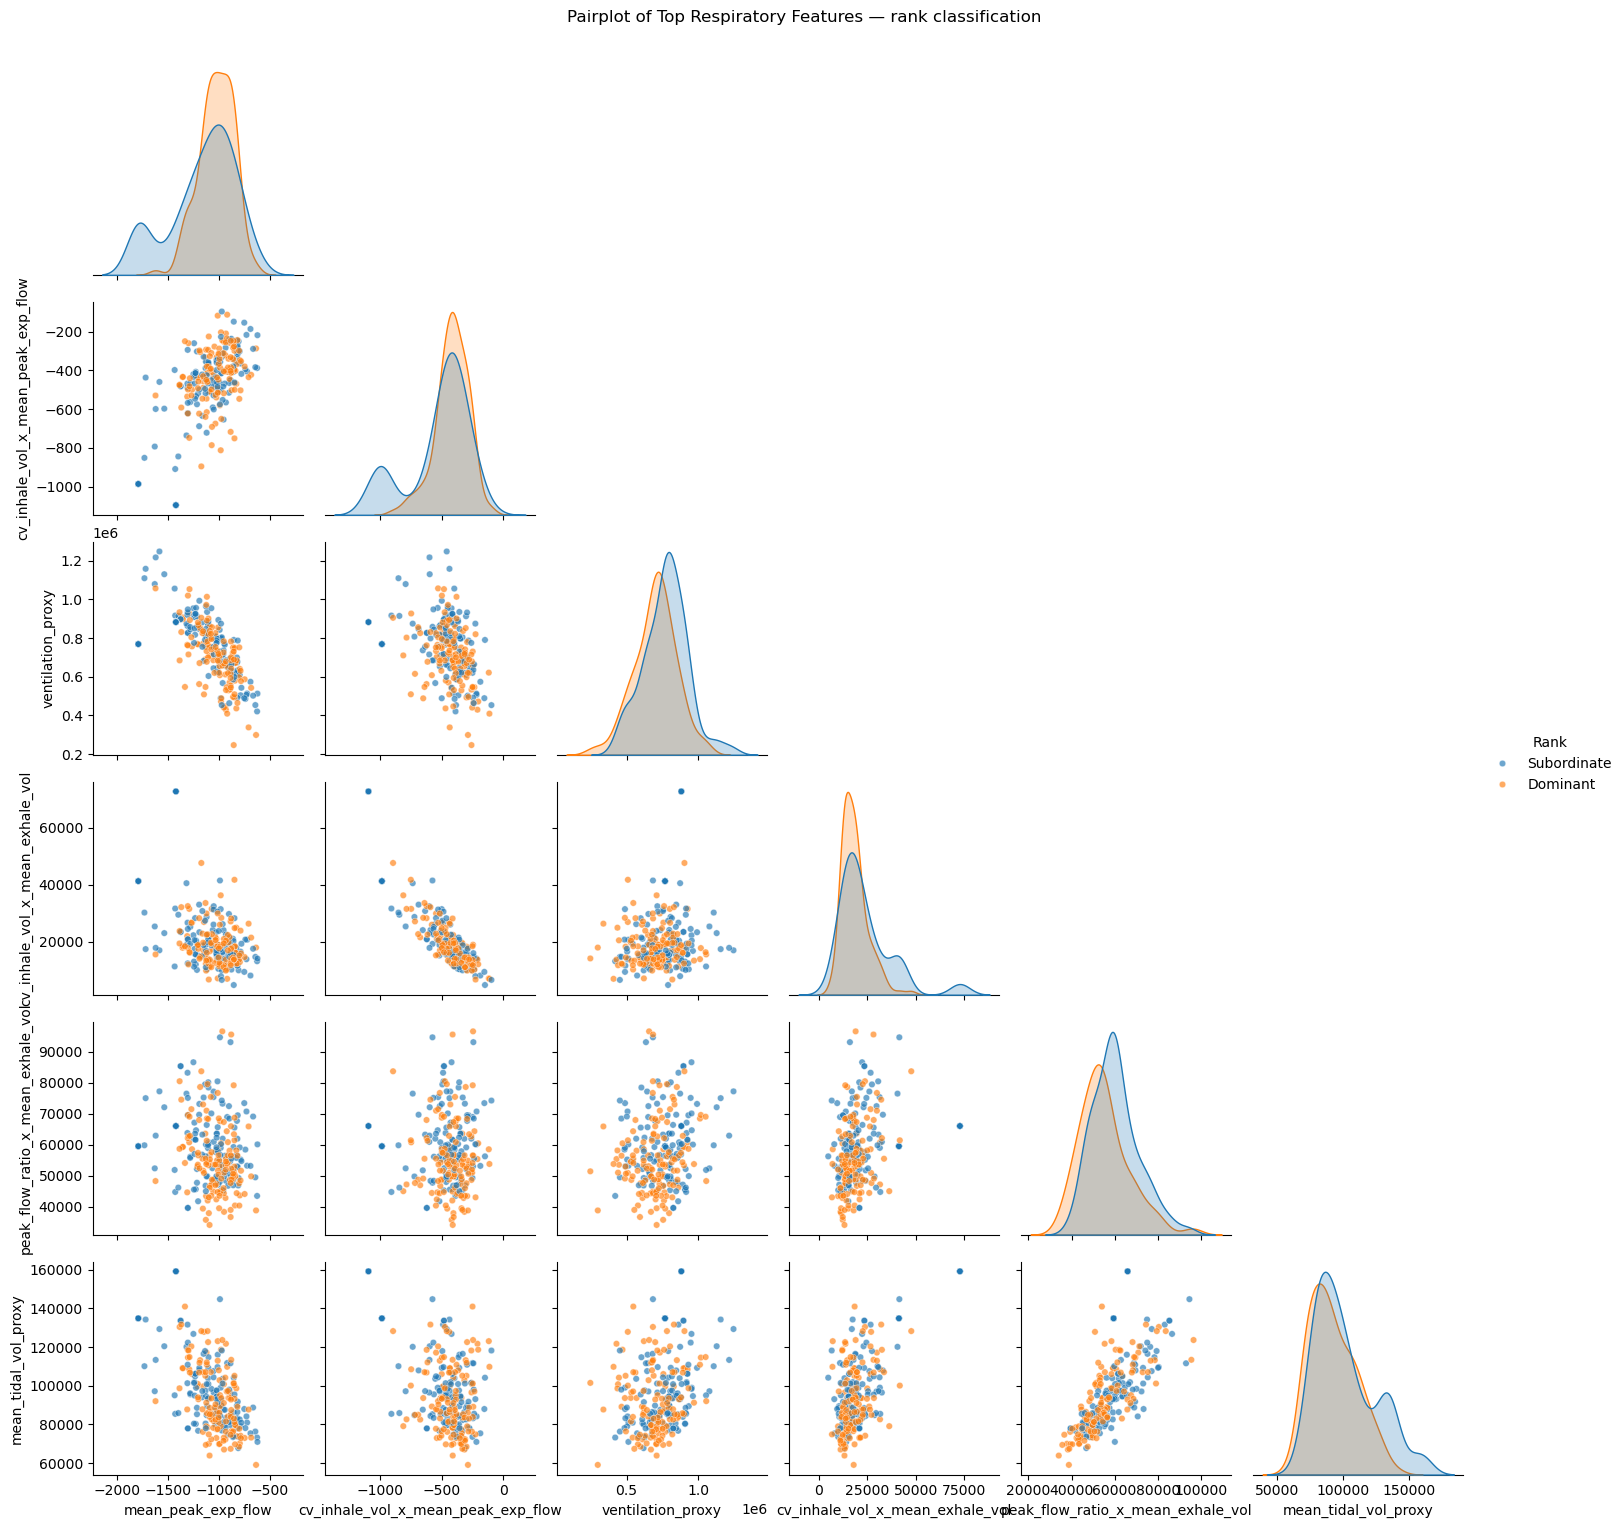

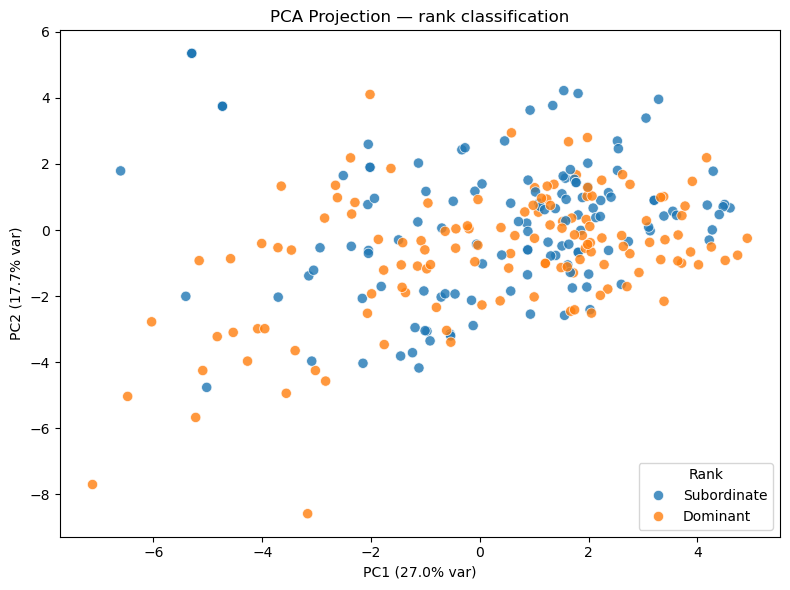

Total variance explained by PC1+PC2: 44.64%


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import f_classif

N_TOP_FEATURES = 6


def inspect_pairplot_and_pca(prep, dataset_name, n_top_features=N_TOP_FEATURES):
    """Pairplot + PCA for one dataset split."""
    X_local = prep["X"]
    y_local = prep["y"]

    print("\n" + "=" * 80)
    print(f"FEATURE INSPECTION — {dataset_name}")
    print("=" * 80)

    imputer = SimpleImputer(strategy="median")
    X_vis = pd.DataFrame(imputer.fit_transform(X_local), columns=X_local.columns, index=X_local.index)

    f_scores, _ = f_classif(X_vis, y_local)
    feature_rank = pd.Series(f_scores, index=X_vis.columns).sort_values(ascending=False)
    top_features = feature_rank.head(n_top_features).index.tolist()

    print("Top features used in pairplot:", top_features)
    display(feature_rank.head(12).to_frame(name="anova_f_score"))

    pairplot_df = X_vis[top_features].copy()
    pairplot_df[TARGET_COL] = y_local.values

    g = sns.pairplot(
        pairplot_df,
        hue=TARGET_COL,
        corner=True,
        diag_kind="kde",
        plot_kws={"alpha": 0.65, "s": 22},
    )
    g.fig.suptitle(f"Pairplot of Top Respiratory Features — {dataset_name}", y=1.02)
    plt.show()

    X_vis_scaled = pd.DataFrame(
        StandardScaler().fit_transform(X_vis),
        columns=X_vis.columns,
        index=X_vis.index,
    )
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_vis_scaled)

    pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X_vis.index)
    pca_df[TARGET_COL] = y_local.values

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=TARGET_COL, alpha=0.8, s=55)
    plt.title(f"PCA Projection — {dataset_name}")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
    plt.legend(title=TARGET_COL)
    plt.tight_layout()
    plt.show()

    print(
        f"Total variance explained by PC1+PC2: "
        f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
    )


inspect_pairplot_and_pca(prep, "rank classification")

### PCA - Seperating by Behavior in Case Facial Sniffing for rank might be different than Ano for example


FEATURE INSPECTION — rank classification — Behavior: facial sniffing
Top features used in pairplot: ['cv_inhale_vol_x_mean_peak_exp_flow', 'cv_inhale_vol_x_mean_exhale_vol', 'cv_inhale_vol', 'mean_peak_exp_flow', 'mean_tidal_vol_proxy', 'mean_peak_insp_flow']


,anova_f_score
cv_inhale_vol_x_mean_peak_exp_flow,21.341639
cv_inhale_vol_x_mean_exhale_vol,15.549260
cv_inhale_vol,10.803673
mean_peak_exp_flow,9.063616
mean_tidal_vol_proxy,9.059210
mean_peak_insp_flow,7.991295
mean_inhale_vol,7.306115
ventilation_proxy,6.921206
peak_flow_ratio_x_mean_exhale_vol,6.580659
mean_exhale_vol,5.706562


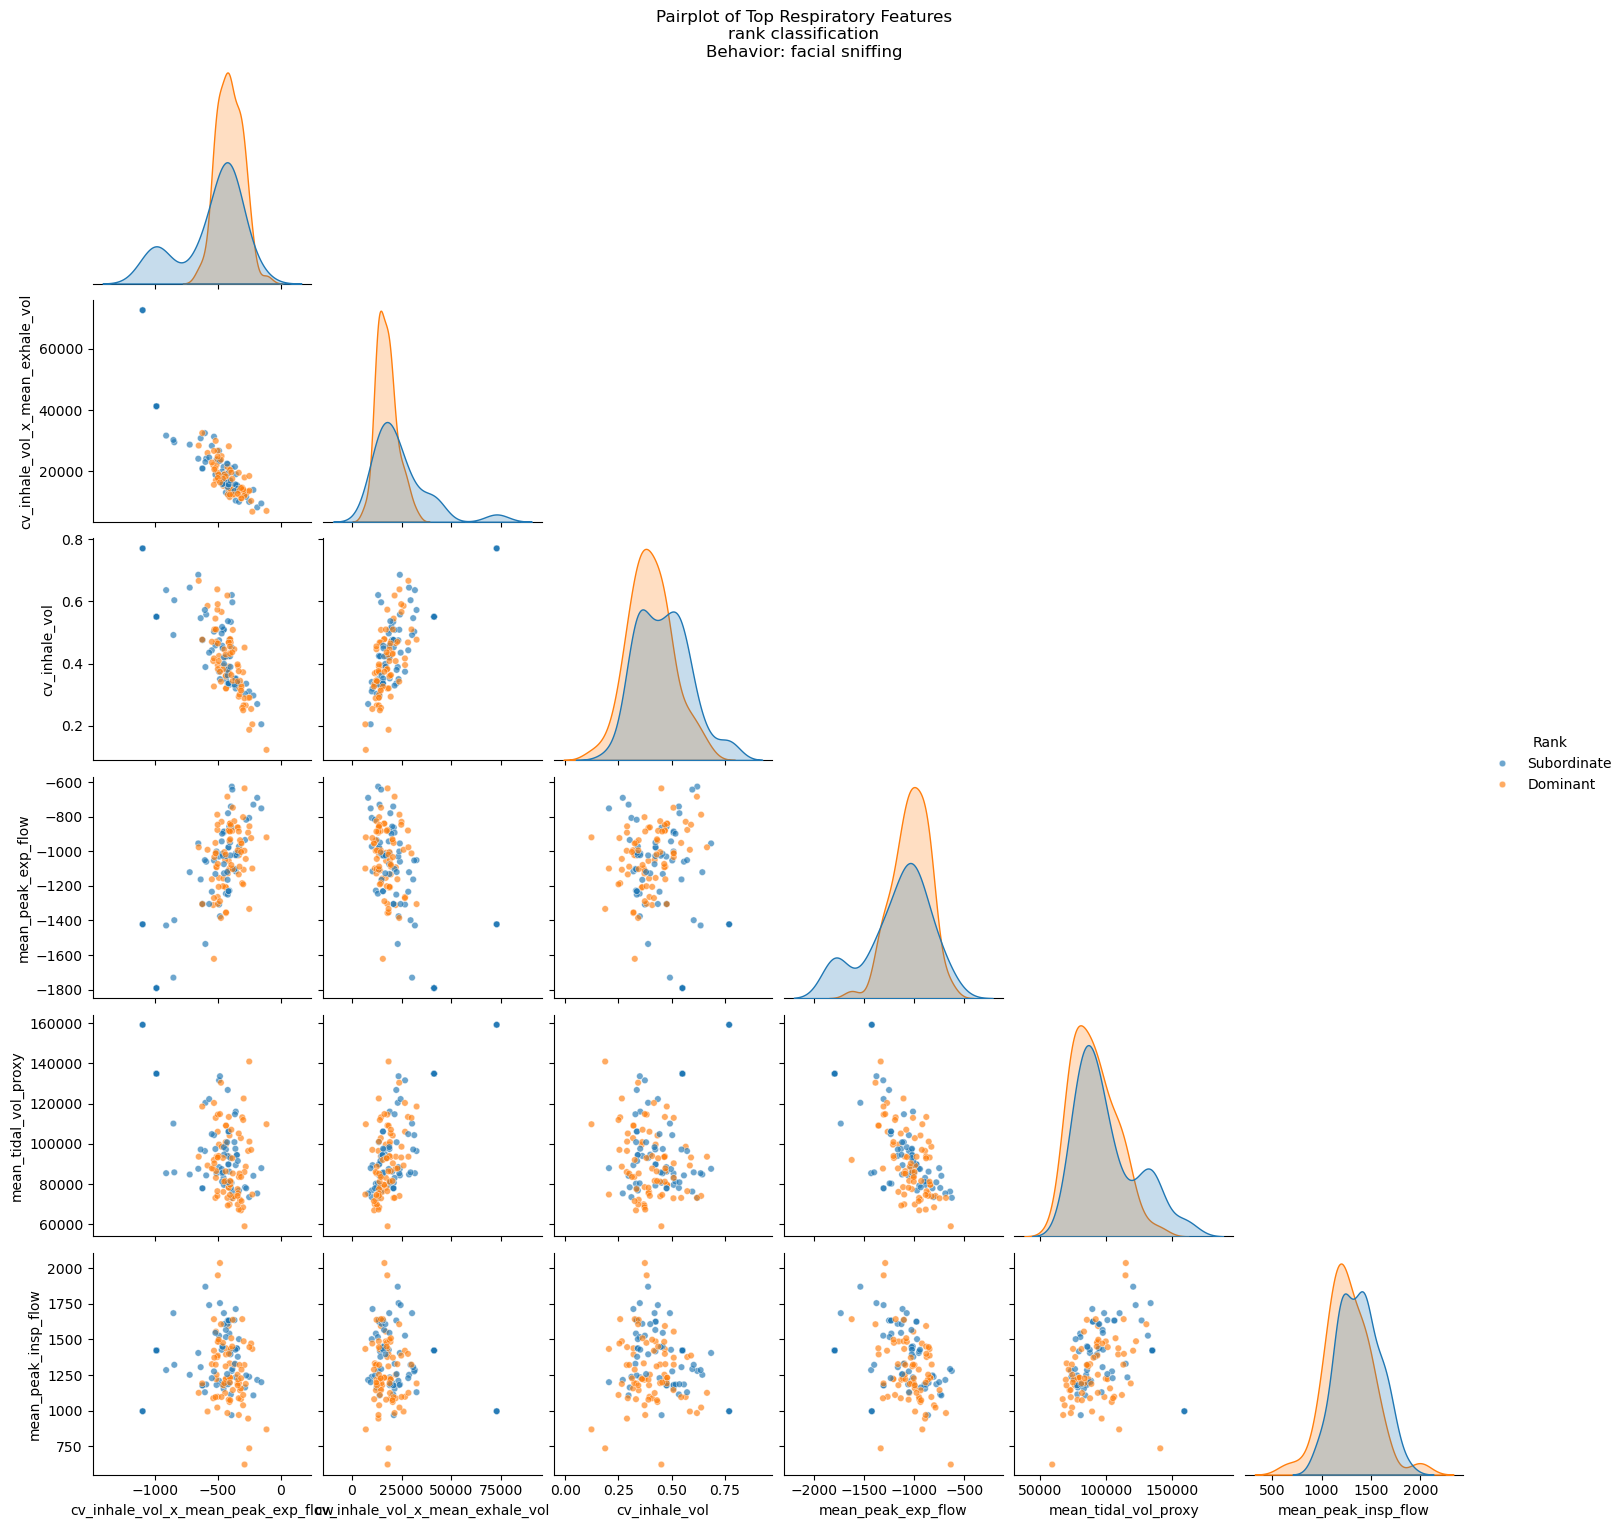

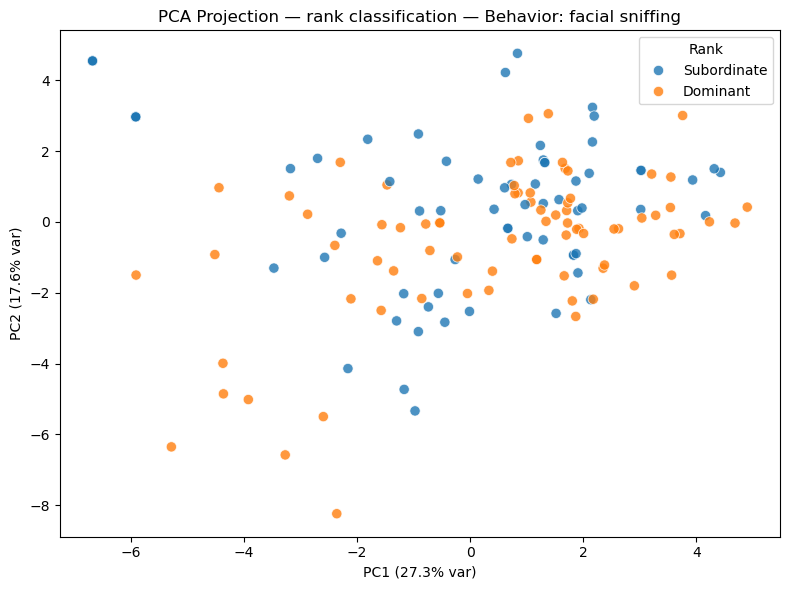

Total variance explained by PC1+PC2: 44.90%

FEATURE INSPECTION — rank classification — Behavior: body sniffing
Top features used in pairplot: ['mean_peak_exp_flow', 'exhale_duty_cycle', 'mean_exhale_pause_dur_sec', 'ventilation_proxy', 'mean_exhale_vol', 'pct_breaths_with_exhale_pause']


,anova_f_score
mean_peak_exp_flow,8.345990
exhale_duty_cycle,7.861569
mean_exhale_pause_dur_sec,7.327079
ventilation_proxy,7.123624
mean_exhale_vol,6.283958
pct_breaths_with_exhale_pause,6.277952
cv_exhale_dur,5.341115
exhale_pause_duty_cycle,5.291089
cv_inhale_vol_x_peak_flow_ratio,3.949296
mean_tidal_vol_proxy,3.815932


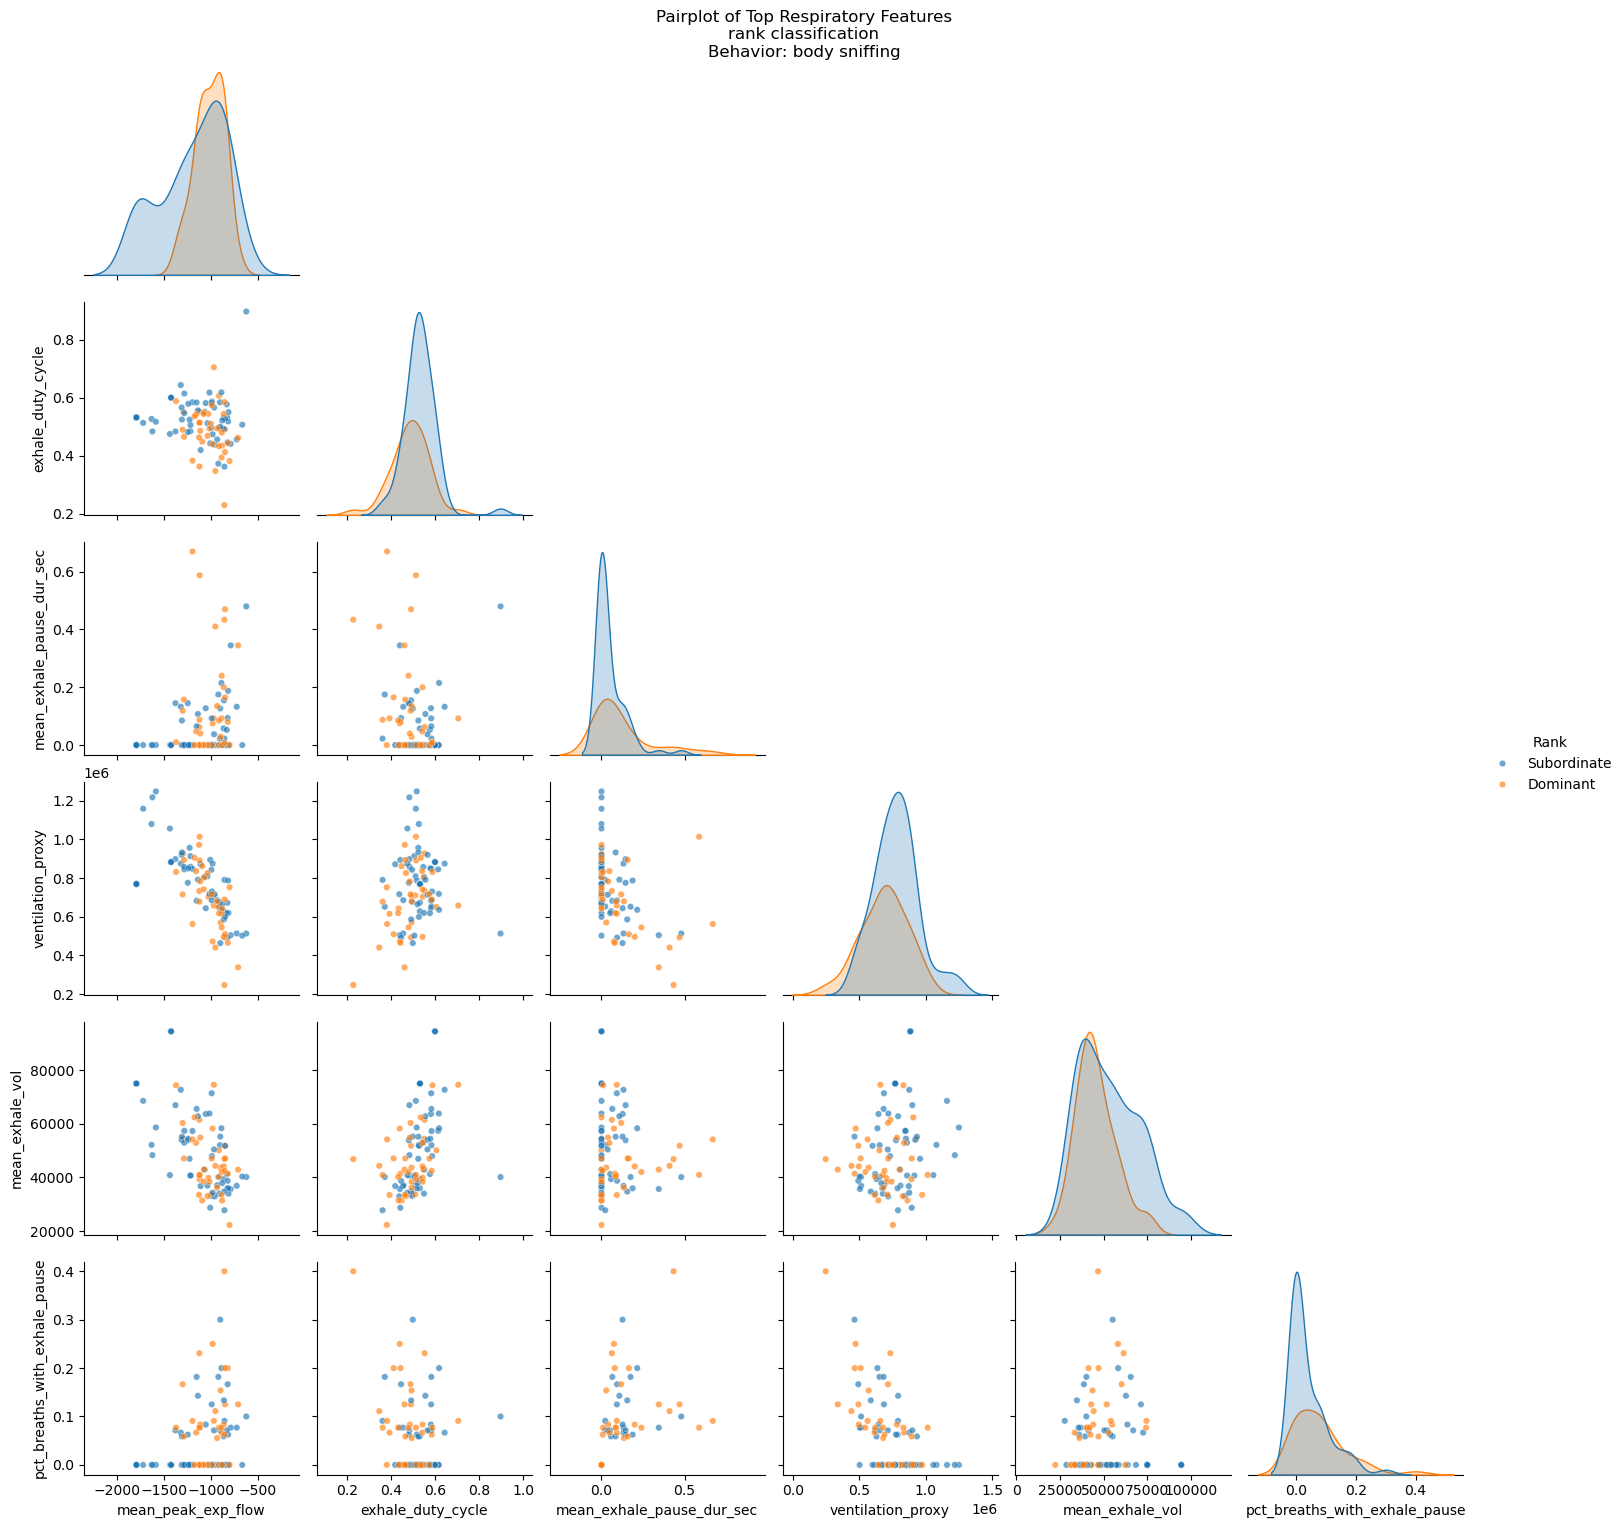

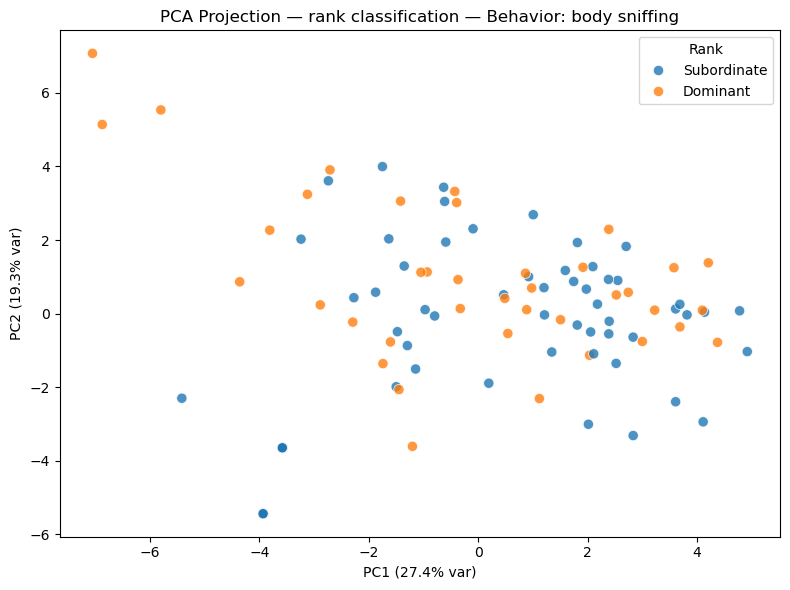

Total variance explained by PC1+PC2: 46.70%

FEATURE INSPECTION — rank classification — Behavior: anogenital sniffing
Top features used in pairplot: ['peak_flow_ratio_x_mean_exhale_vol', 'mean_peak_insp_flow', 'exhale_pause_duty_cycle', 'mean_exhale_pause_dur_sec', 'cv_exhale_dur', 'ie_ratio']


,anova_f_score
peak_flow_ratio_x_mean_exhale_vol,6.162967
mean_peak_insp_flow,5.582723
exhale_pause_duty_cycle,4.323273
mean_exhale_pause_dur_sec,2.764338
cv_exhale_dur,2.689212
ie_ratio,2.651682
exhale_duty_cycle,2.198075
inhale_duty_cycle,2.135565
cv_peak_insp_flow,1.771651
ventilation_proxy,1.766303


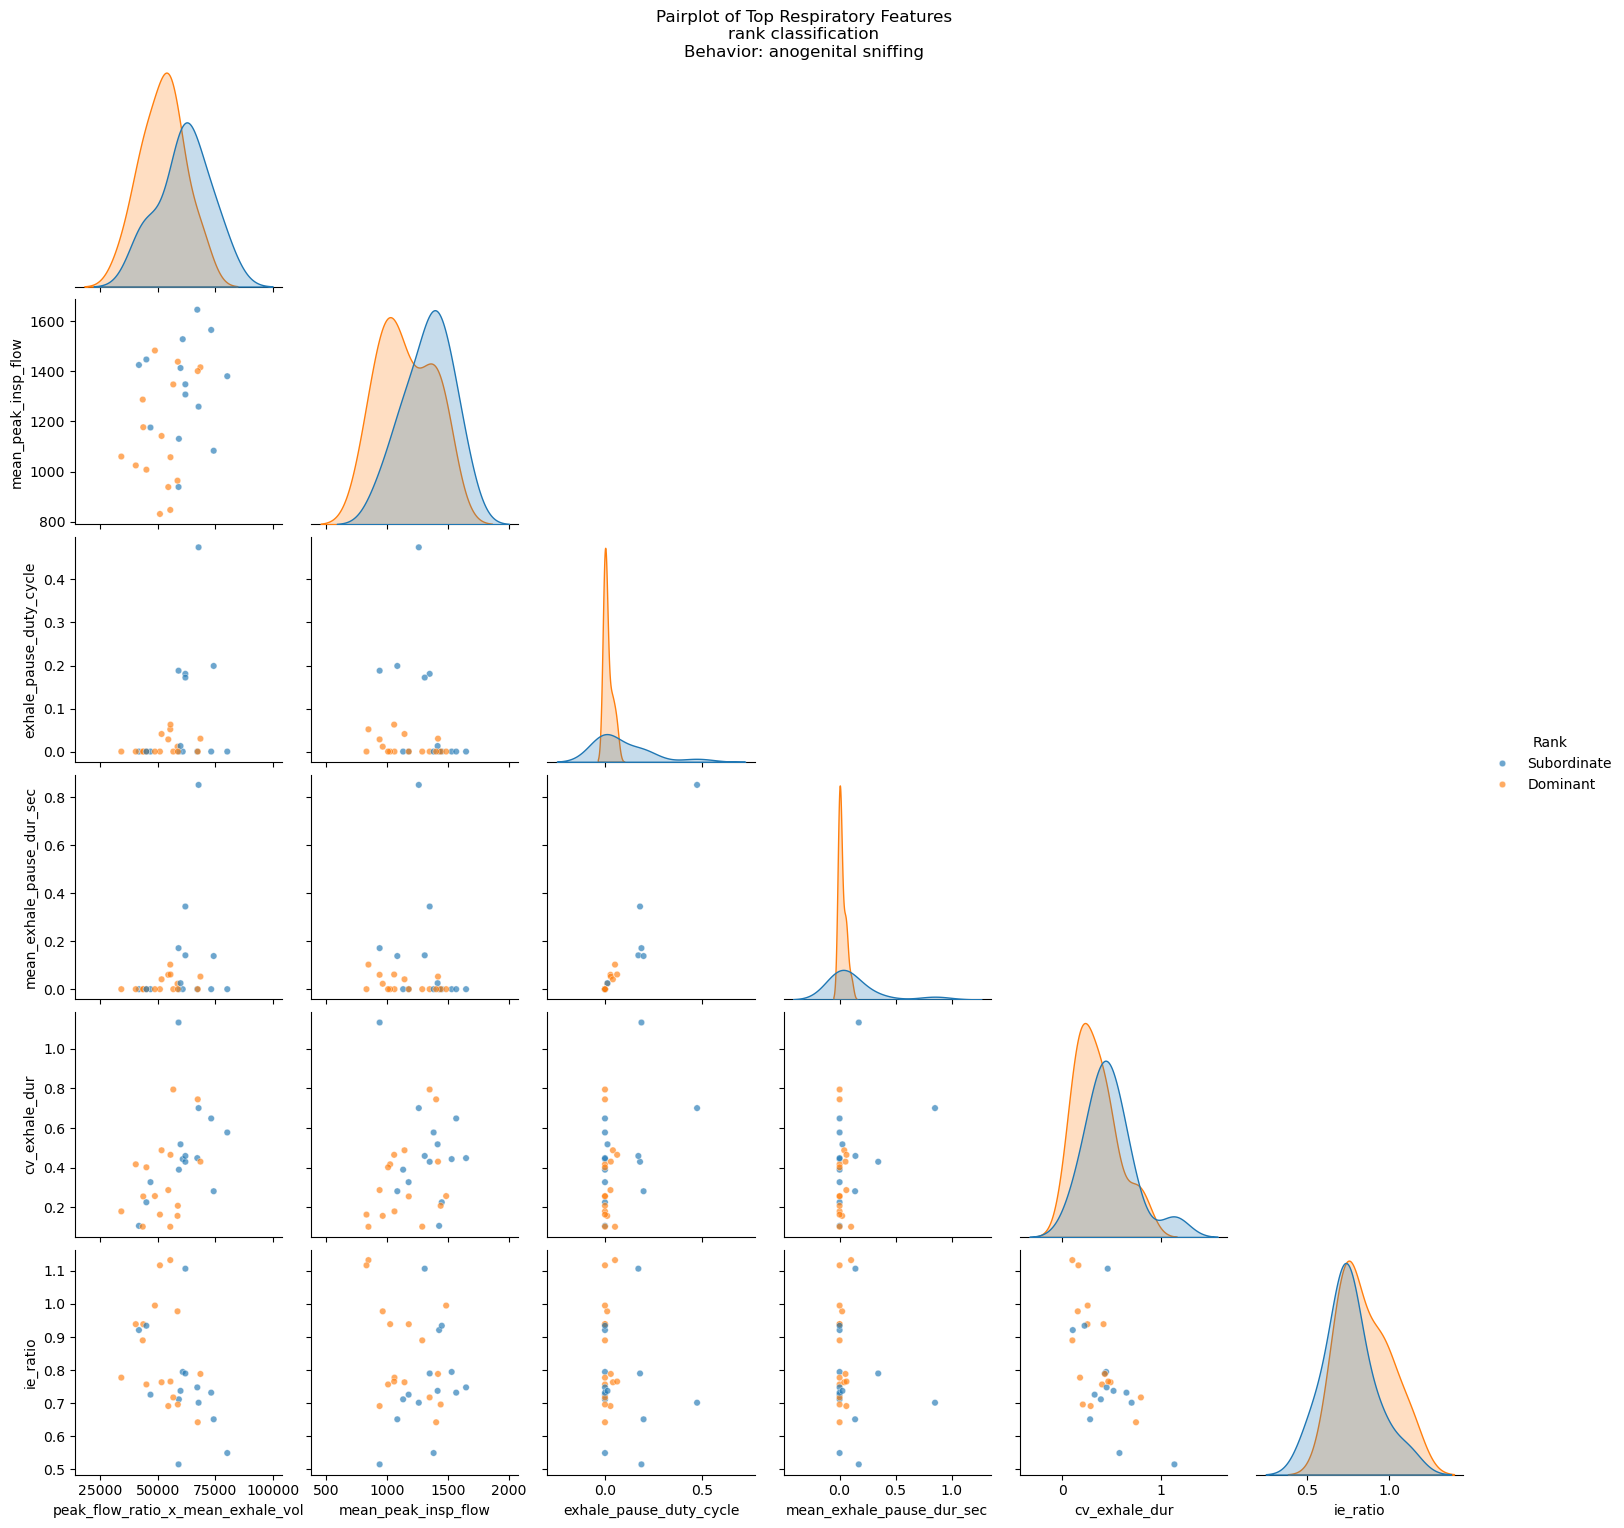

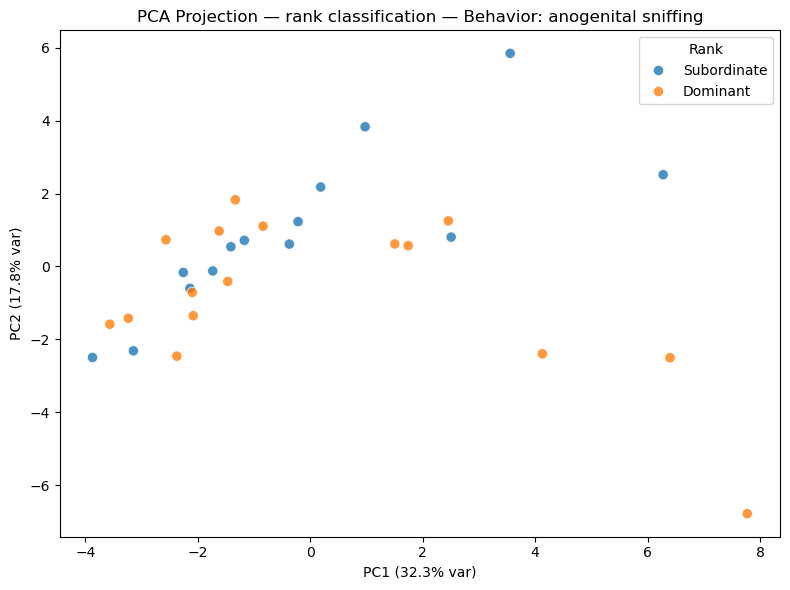

Total variance explained by PC1+PC2: 50.13%


In [ ]:
# Do the same top respiratory feature/ANOVA/PCA visualization, but separate by behavior instead of rank

def inspect_pairplot_and_pca_by_behavior(prep, dataset_name, n_top_features=N_TOP_FEATURES):
    """
    For each behavior, plot the top features' pairplot and PCA scatter plot.
    """
    X_local = prep["X"]
    y_local = prep["y"]

    df = prep.get("df")
    if df is None or "Behavior" not in df.columns:
        print(f"✗ No dataframe or missing 'Behavior' column for {dataset_name}")
        return

    behaviors = df["Behavior"].dropna().unique()
    for behavior in behaviors:
        behavior_mask = df["Behavior"] == behavior
        X_b = X_local.loc[behavior_mask]
        y_b = y_local.loc[behavior_mask]

        print("\n" + "=" * 80)
        print(f"FEATURE INSPECTION — {dataset_name} — Behavior: {behavior}")
        print("=" * 80)

        imputer = SimpleImputer(strategy="median")
        X_vis = pd.DataFrame(imputer.fit_transform(X_b), columns=X_b.columns, index=X_b.index)

        f_scores, _ = f_classif(X_vis, y_b)
        feature_rank = pd.Series(f_scores, index=X_vis.columns).sort_values(ascending=False)
        top_features = feature_rank.head(n_top_features).index.tolist()

        print("Top features used in pairplot:", top_features)
        display(feature_rank.head(12).to_frame(name="anova_f_score"))

        pairplot_df = X_vis[top_features].copy()
        pairplot_df[TARGET_COL] = y_b.values

        g = sns.pairplot(
            pairplot_df,
            hue=TARGET_COL,
            corner=True,
            diag_kind="kde",
            plot_kws={"alpha": 0.65, "s": 22},
        )
        g.fig.suptitle(f"Pairplot of Top Respiratory Features\n{dataset_name}\nBehavior: {behavior}", y=1.02)
        plt.show()

        X_vis_scaled = pd.DataFrame(
            StandardScaler().fit_transform(X_vis),
            columns=X_vis.columns,
            index=X_vis.index,
        )
        pca = PCA(n_components=2, random_state=42)
        X_pca = pca.fit_transform(X_vis_scaled)

        pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X_vis.index)
        pca_df[TARGET_COL] = y_b.values

        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=TARGET_COL, alpha=0.8, s=55)
        plt.title(f"PCA Projection — {dataset_name} — Behavior: {behavior}")
        plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
        plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
        plt.legend(title=TARGET_COL)
        plt.tight_layout()
        plt.show()

        print(
            f"Total variance explained by PC1+PC2: "
            f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
        )

inspect_pairplot_and_pca_by_behavior(prep, "rank classification")

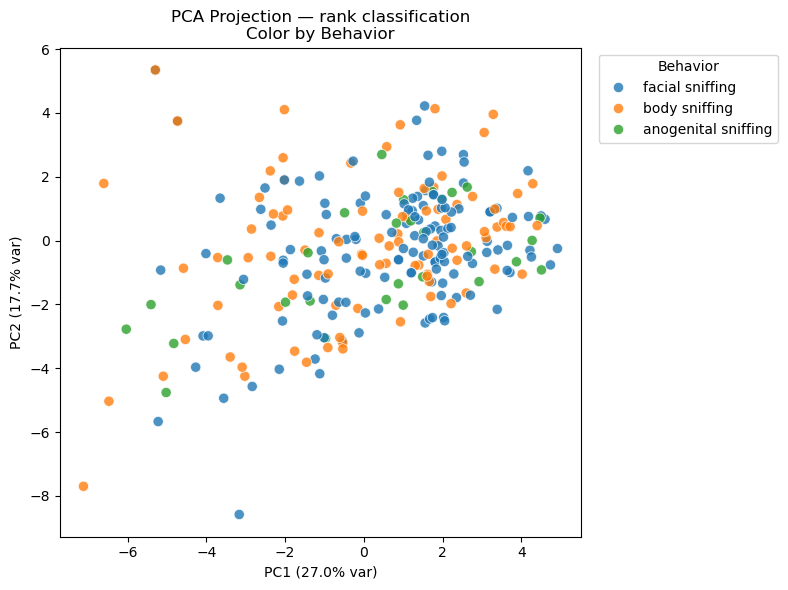

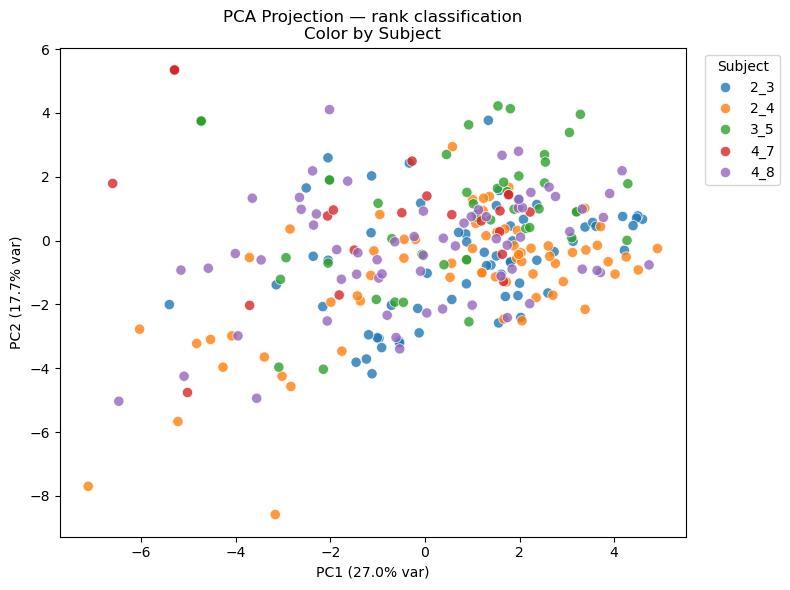

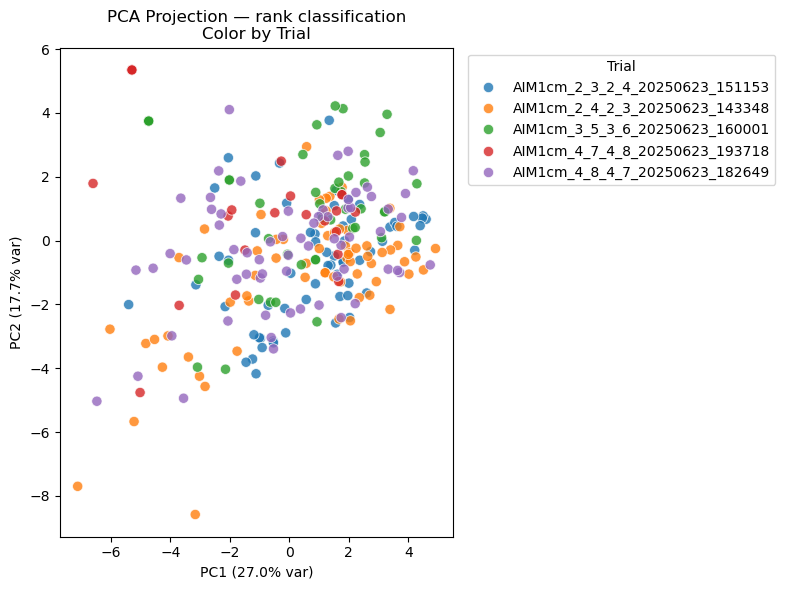

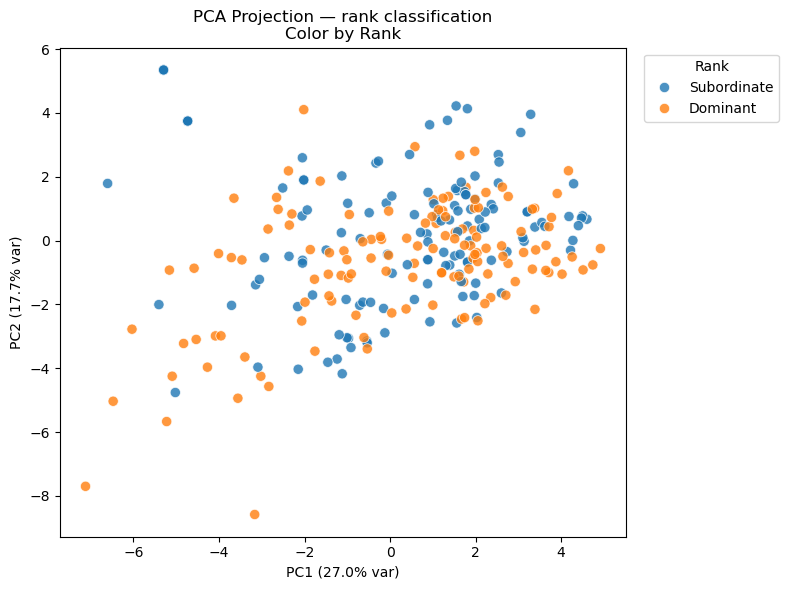

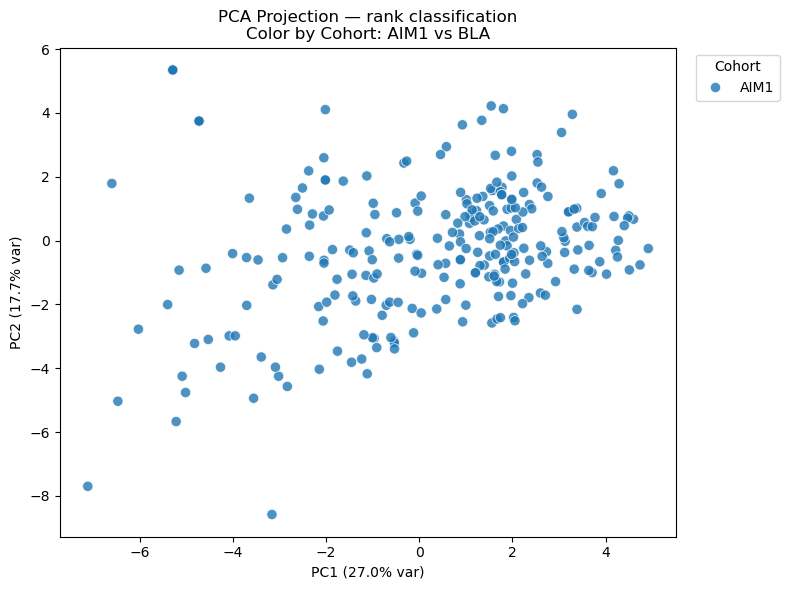

Total variance explained by PC1+PC2: 44.64%


In [ ]:
# PCA scatterplots coloring by Behavior, Subject, Trial, Condition, Rank (over all inputs)
# Assumes prep, TARGET_COL

from sklearn.preprocessing import StandardScaler

dataset_name_to_plot = "rank classification"
X_local = prep["X"]
y_local = prep["y"]
df = prep.get("df")

if df is not None:
    # Impute missing values for the PCA
    imputer = SimpleImputer(strategy="median")
    X_vis = pd.DataFrame(imputer.fit_transform(X_local), columns=X_local.columns, index=X_local.index)
    X_vis_scaled = pd.DataFrame(
        StandardScaler().fit_transform(X_vis),
        columns=X_vis.columns,
        index=X_vis.index,
    )

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_vis_scaled)

    # Build composite dataframe for plotting with metadata columns
    pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X_vis.index)
    for col in ["Behavior", "Subject", "Trial", "Condition", "Rank", "Cohort"]:
        if col in df.columns:
            pca_df[col] = df.loc[X_vis.index, col]
    # Always add target col for reference
    pca_df[TARGET_COL] = y_local.values

    color_cols = []
    # Only plot for columns that exist in the df
    for col in ["Behavior", "Subject", "Trial", "Condition", "Rank"]:
        if col in pca_df.columns:
            color_cols.append(col)

    for ccol in color_cols:
        plt.figure(figsize=(8, 6))
        _palette = "tab10" if pca_df[ccol].nunique() <= 10 else "tab20"
        sns.scatterplot(
            data=pca_df,
            x="PC1",
            y="PC2",
            hue=ccol,
            palette=_palette,
            alpha=0.8,
            s=55,
        )
        plt.title(f"PCA Projection — {dataset_name_to_plot}\nColor by {ccol}")
        plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
        plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
        plt.legend(title=ccol, bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    # --- ADDITION: PCA plot for aim1 vs bla (Cohort column) ---
    # If 'Cohort' column exists, simplify to two major cohorts, then plot
    if "Cohort" in pca_df.columns:
        # Map cohorts: try to identify 'BLA' and 'AIM1' in cohort names case-insensitively
        cohort_map = {}
        unique_cohorts = pca_df["Cohort"].unique()
        for c in unique_cohorts:
            c_lower = str(c).lower()
            if "aim1" in c_lower:
                cohort_map[c] = "AIM1"
            elif "bla" in c_lower:
                cohort_map[c] = "BLA"
            else:
                cohort_map[c] = "Other"
        pca_df["Cohort_BLA_AIM1"] = pca_df["Cohort"].map(cohort_map)
        # Optionally filter out "Other"
        subset_pca_df = pca_df[pca_df["Cohort_BLA_AIM1"].isin(["AIM1", "BLA"])].copy()
        if not subset_pca_df.empty:
            plt.figure(figsize=(8, 6))
            sns.scatterplot(
                data=subset_pca_df,
                x="PC1",
                y="PC2",
                hue="Cohort_BLA_AIM1",
                palette={"AIM1": "C0", "BLA": "C1"},
                alpha=0.8,
                s=55,
            )
            plt.title(f"PCA Projection — {dataset_name_to_plot}\nColor by Cohort: AIM1 vs BLA")
            plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)")
            plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)")
            plt.legend(title="Cohort", bbox_to_anchor=(1.02, 1), loc="upper left")
            plt.tight_layout()
            plt.show()
        else:
            print("Cohort BLA/AIM1 plot: No samples for AIM1 or BLA found in 'Cohort' column.")
    else:
        print("Cohort BLA/AIM1 plot: No 'Cohort' column found.")

    print(
        f"Total variance explained by PC1+PC2: "
        f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
    )
else:
    print("✗ No dataframe 'df' found in the selected dataset to add colorings for metadata columns.")